*ТЕМА*
Сравнительный анализ классических и нейронных рекомендательных систем в сфере электронной коммерции

*ПЛАН*

1. Предобработка данных (создание датасета в разрезе клиентов)
2. Классическая кластеризация на основе табличных признаков - сегментация по клиентам 
3. Рекомендационные системы "классические"
4. Нейронные рекомендательные системы
5. Сравнение рекомендательных систем


In [1]:
import sys
print(sys.executable) 
print(sys.prefix) 


/Users/ekaterinazinoveva/Mag/bin/python
/Users/ekaterinazinoveva/Mag


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
import hdbscan
from sklearn.manifold import TSNE
import umap
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
import openpyxl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, average_precision_score
from sklearn.compose import ColumnTransformer

In [3]:
#! /Users/ekaterinazinoveva/Mag/bin/python -m pip install openpyxl

In [3]:
def describe_columns(df):
    data = []
    for column in df.columns:
        data.append([
            column,
            df[column].nunique(),
            (df[column] == 0).sum(),
            df[column].isna().sum(),
            round(df[column].isna().sum() / len(df) * 100, 1),
            df[column].dtypes
        ])
    
    result_df = pd.DataFrame(data, columns=['Column', 'Count Unique', 'Count Zeros', 'Count NaNs', '% of NaNs', 'data type'])
    print(result_df.to_string(index=False))

In [4]:
file_list = [
    f'!01_02_17_VSE.csv',
    f'!03&04_17_VSE.csv',
    f'!05&06_17_VSE.csv',
    f'!07&08_17_VSE.csv',
    f'!09_10_17_VSE.csv',
    f'!11_17_VSE.csv',
    f'!01_02-18_VSE.csv'
]

df = pd.concat([pd.read_csv(file, encoding='windows-1251', sep=';') for file in file_list], ignore_index=True)

/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_37946/2622506937.py:11: DtypeWarning: Columns (27,28,32,33,34,35,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(file, encoding='windows-1251', sep=';') for file in file_list], ignore_index=True)
/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_37946/2622506937.py:11: DtypeWarning: Columns (9,10,11,14,16,20,26,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat([pd.read_csv(file, encoding='windows-1251', sep=';') for file in file_list], ignore_index=True)


In [5]:
#Проверим файлы по отдельности на соотвествие столбцов
dfs = {} 

for file in file_list:
    df_temp = pd.read_csv(file, encoding='windows-1251', sep=';')
    dfs[file] = df_temp

/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_37946/2196040638.py:5: DtypeWarning: Columns (27,28,32,33,34,35,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file, encoding='windows-1251', sep=';')
/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_37946/2196040638.py:5: DtypeWarning: Columns (9,10,11,14,16,20,26,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file, encoding='windows-1251', sep=';')


In [6]:
dfs['!11_17_VSE.csv']

,Дата,ДатаДоставки,НомерЗаказаНаСайте,НовыйСтатус,СуммаЗаказаНаСайте,СуммаДокумента,МетодДоставки,ФормаОплаты,Регион,Группа2,...,СуммаДоставки,НомерСтроки,КоличествоПроданоКлиенту,ДатаЗаказаНаСайте,Телефон_new,ЭлектроннаяПочта_new,Клиент,ID_SKU,ГородМагазина,МагазинЗаказа
0,01.11.2017 13:40,02.11.2017 0:00,6005006_TR,К отгрузке,4 905,4 905,Курьерская,Наличная,Реутов (Московская область район),КОСМЕТИКА/ГИГИЕНА,...,150,6,2,31.10.2017 0:00,55575453-50495155574879,109117_mu23@list.ru,Мария,ID9010010510048,0,NaN
1,01.11.2017 13:40,02.11.2017 0:00,6005006_TR,К отгрузке,4 905,4 905,Курьерская,Наличная,Реутов (Московская область район),ДЕТСКОЕ ПИТАНИЕ,...,150,3,1,31.10.2017 0:00,55575453-50495155574879,109117_mu23@list.ru,Мария,ID000sm-0703957,0,NaN
2,01.11.2017 13:40,02.11.2017 0:00,6005006_TR,К отгрузке,4 905,4 905,Курьерская,Наличная,Реутов (Московская область район),ДЕТСКОЕ ПИТАНИЕ,...,150,2,1,31.10.2017 0:00,55575453-50495155574879,109117_mu23@list.ru,Мария,ID000sm-0704250,0,NaN
3,01.11.2017 13:40,02.11.2017 0:00,6005006_TR,К отгрузке,4 905,4 905,Курьерская,Наличная,Реутов (Московская область район),NaN,...,150,1,1,31.10.2017 0:00,55575453-50495155574879,109117_mu23@list.ru,Мария,ID10022107250,0,NaN
4,01.11.2017 13:40,02.11.2017 0:00,6005006_TR,К отгрузке,4 905,4 905,Курьерская,Наличная,Реутов (Московская область район),ДЕТСКОЕ ПИТАНИЕ,...,150,4,1,31.10.2017 0:00,55575453-50495155574879,109117_mu23@list.ru,Мария,ID000sm-0705957,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
557068,30.11.2017 23:43,07.12.2017 0:00,6434322_TR,Доставлен,4 720,4 720,Магазины,Безналичная,Москва,ТОВАРЫ ДЛЯ КОРМЛЕНИЯ,...,0,4,1,30.11.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN
557069,30.11.2017 23:43,07.12.2017 0:00,6434322_TR,Доставлен,4 720,4 720,Магазины,Безналичная,Москва,ТОВАРЫ ДЛЯ КОРМЛЕНИЯ,...,0,6,1,30.11.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN
557070,30.11.2017 23:43,07.12.2017 0:00,6434322_TR,Доставлен,4 720,4 720,Магазины,Безналичная,Москва,ТОВАРЫ ДЛЯ КОРМЛЕНИЯ,...,0,7,1,30.11.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN
557071,30.11.2017 23:43,07.12.2017 0:00,6434322_TR,Доставлен,4 720,4 720,Магазины,Безналичная,Москва,КОСМЕТИКА/ГИГИЕНА,...,0,3,1,30.11.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
#Проверим столбцы всех файлов
columns_list = []
for file in file_list:
    df_temp = pd.read_csv(file, encoding='windows-1251', sep=';')
    columns_list.append(df_temp.columns.tolist())
max_len = max(len(cols) for cols in columns_list)

# Выравниваем списки по длине, заполняя пустыми строками
aligned = []
for cols in columns_list:
    cols_extended = cols + [""] * (max_len - len(cols))
    aligned.append(cols_extended)

cols_df = pd.DataFrame(
    {file_list[i]: aligned[i] for i in range(len(file_list))}
)

cols_df

/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_37946/581461736.py:4: DtypeWarning: Columns (27,28,32,33,34,35,36,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file, encoding='windows-1251', sep=';')
/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_37946/581461736.py:4: DtypeWarning: Columns (9,10,11,14,16,20,26,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(file, encoding='windows-1251', sep=';')


,!01_02_17_VSE.csv,!03&04_17_VSE.csv,!05&06_17_VSE.csv,!07&08_17_VSE.csv,!09_10_17_VSE.csv,!11_17_VSE.csv,!01_02-18_VSE.csv
0,Дата,Дата,Дата,Дата,Дата,Дата,Дата
1,ДатаДоставки,ДатаДоставки,ДатаДоставки,ДатаДоставки,ДатаДоставки,ДатаДоставки,ДатаДоставки
2,НомерЗаказаНаСайте,НомерЗаказаНаСайте,НомерЗаказаНаСайте,НомерЗаказаНаСайте,НомерЗаказаНаСайте,НомерЗаказаНаСайте,НомерЗаказаНаСайте
3,НовыйСтатус,НовыйСтатус,НовыйСтатус,НовыйСтатус,НовыйСтатус,НовыйСтатус,НовыйСтатус
4,СуммаЗаказаНаСайте,СуммаЗаказаНаСайте,СуммаЗаказаНаСайте,СуммаЗаказаНаСайте,СуммаЗаказаНаСайте,СуммаЗаказаНаСайте,СуммаЗаказаНаСайте
5,СуммаДокумента,СуммаДокумента,СуммаДокумента,СуммаДокумента,СуммаДокумента,СуммаДокумента,СуммаДокумента
6,МетодДоставки,МетодДоставки,МетодДоставки,МетодДоставки,МетодДоставки,МетодДоставки,МетодДоставки
7,ФормаОплаты,ФормаОплаты,ФормаОплаты,ФормаОплаты,ФормаОплаты,ФормаОплаты,ФормаОплаты
8,Регион,Регион,Регион,Регион,Регион,Регион,Регион
9,Группа2,Группа2,Группа2,Группа2,Группа2,Группа2,Группа2


In [8]:
file_with_tab = f'!12_17_VSE.csv'
df_tab = pd.read_csv(file_with_tab, encoding='windows-1251', sep='\t')

/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_37946/3422330114.py:2: DtypeWarning: Columns (32,33,34,35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tab = pd.read_csv(file_with_tab, encoding='windows-1251', sep='\t')


In [9]:
df_tab
df = pd.concat([df, df_tab], ignore_index=True)

In [10]:
df_tab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 626614 entries, 0 to 626613
Data columns (total 38 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   Дата                      626614 non-null  object
 1   ДатаДоставки              626157 non-null  object
 2   НомерЗаказаНаСайте        626614 non-null  object
 3   НовыйСтатус               626614 non-null  object
 4   СуммаЗаказаНаСайте        626614 non-null  object
 5   СуммаДокумента            626614 non-null  object
 6   МетодДоставки             626583 non-null  object
 7   ФормаОплаты               626583 non-null  object
 8   Регион                    623886 non-null  object
 9   Группа2                   517505 non-null  object
 10  Группа3                   517503 non-null  object
 11  Группа4                   497843 non-null  object
 12  Тип                       626614 non-null  object
 13  Номенклатура              626614 non-null  object
 14  ТипТ

In [11]:
#Сохраняем исходный датафрейм
data=df

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5515264 entries, 0 to 5515263
Data columns (total 39 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Дата                      object 
 1   ДатаДоставки              object 
 2   НомерЗаказаНаСайте        object 
 3   НовыйСтатус               object 
 4   СуммаЗаказаНаСайте        object 
 5   СуммаДокумента            object 
 6   МетодДоставки             object 
 7   ФормаОплаты               object 
 8   Регион                    object 
 9   Группа2                   object 
 10  Группа3                   object 
 11  Группа4                   object 
 12  Тип                       object 
 13  Номенклатура              object 
 14  ТипТовара                 object 
 15  Отменено                  object 
 16  ПричинаОтмены             object 
 17  Количество                int64  
 18  Цена                      object 
 19  СуммаСтроки               object 
 20  ЦенаЗакупки             

In [13]:
df

,Дата,ДатаДоставки,НомерЗаказаНаСайте,НовыйСтатус,СуммаЗаказаНаСайте,СуммаДокумента,МетодДоставки,ФормаОплаты,Регион,Группа2,...,НомерСтроки,КоличествоПроданоКлиенту,ДатаЗаказаНаСайте,Телефон_new,ЭлектроннаяПочта_new,Клиент,ID_SKU,ГородМагазина,МагазинЗаказа,МесяцДатыЗаказа
0,01.01.2017 17:15,04.01.2017 0:00,3530280_TR,Возврат из ПВЗ,2 800,2 800,Магазины,Безналичная,Москва,"ТЕКСТИЛЬ, ТРИКОТАЖ",...,2.0,0,01.01.2017 0:00,55575454-49504949555170,110109_nm19@gmail.com,Анжелика,IDL00023865048,0,NaN,NaN
1,01.01.2017 17:15,04.01.2017 0:00,3530280_TR,Возврат из ПВЗ,2 800,2 800,Магазины,Безналичная,Москва,"ТЕКСТИЛЬ, ТРИКОТАЖ",...,1.0,0,01.01.2017 0:00,55575454-49504949555170,110109_nm19@gmail.com,Анжелика,IDL00022519452,0,NaN,NaN
2,01.01.2017 17:38,03.01.2017 0:00,3530303_TR,К отгрузке,3 585,3 585,Курьерская,Наличная,Москва,ПОДГУЗНИКИ,...,1.0,0,01.01.2017 0:00,55574851-55555555555176,49117_1u16@mail.ru,Anastasia,IDL00038454553,0,NaN,NaN
3,01.01.2017 17:38,04.01.2017 0:00,3530318_TR,Доставлен,2 510,2 510,Магазины,Безналичная,Москва,"ТЕКСТИЛЬ, ТРИКОТАЖ",...,1.0,1,02.01.2017 0:00,55575054-56575354545171,115117_su21@mail.ru,Гость,IDL00035301654,0,NaN,NaN
4,01.01.2017 17:38,02.01.2017 0:00,3530313_TR,К отгрузке,1 069,1 069,Самовывоз,Наличная,Санкт-Петербург,ИГРУШКИ,...,1.0,1,02.01.2017 0:00,55575149-50524951545076,106117_ju18@yandex.ru,Гость,ID9010025983048,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5515259,31.12.2017 23:56,13.01.2018 0:00,6945534_TR,Доставлен,971,971,Магазины,Безналичная,Самара,NaN,...,1.0,0,31.12.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN,12.0
5515260,31.12.2017 23:59,13.01.2018 0:00,6945524_TR,Доставлен,1 179,1 179,Магазины,Безналичная,Белгород,NaN,...,1.0,0,31.12.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN,12.0
5515261,31.12.2017 23:59,13.01.2018 0:00,6945524_TR,Доставлен,1 179,1 179,Магазины,Безналичная,Белгород,ИГРУШКИ,...,1.0,0,31.12.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN,12.0
5515262,31.12.2017 23:59,04.01.2018 0:00,6945526_TR,Отменен,7 049,150,Курьерская,Наличная,Москва,NaN,...,1.0,0,31.12.2017 0:00,NaN,NaN,NaN,NaN,NaN,NaN,12.0


In [14]:
df[['МесяцДаты Заказа','МесяцДатыЗаказа']]

,МесяцДаты Заказа,МесяцДатыЗаказа
0,1.0,NaN
1,1.0,NaN
2,1.0,NaN
3,1.0,NaN
4,1.0,NaN
...,...,...
5515259,NaN,12.0
5515260,NaN,12.0
5515261,NaN,12.0
5515262,NaN,12.0


In [154]:
df[['Маржа','Цена','Количество']]

,Маржа,Цена,Количество
3081138,94.06,959.0,1
429687,0.50,2000.0,1
3273505,209.97,999.0,1
3273506,21.79,140.0,1
3273507,23.00,139.0,1
...,...,...,...
4553177,-269.43,879.0,1
4549050,531.00,1140.0,1
4547471,1852.00,18600.0,1
4531457,699.00,1354.0,1


In [15]:
df[['МесяцДаты Заказа','МесяцДатыЗаказа']].notna().all(axis=1).sum()

np.int64(0)

In [16]:
df['МесяцЗаказа'] = df['МесяцДаты Заказа'].combine_first(df['МесяцДатыЗаказа'])
df = df.drop(['МесяцДаты Заказа', 'МесяцДатыЗаказа'], axis=1)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5515264 entries, 0 to 5515263
Data columns (total 38 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Дата                      object 
 1   ДатаДоставки              object 
 2   НомерЗаказаНаСайте        object 
 3   НовыйСтатус               object 
 4   СуммаЗаказаНаСайте        object 
 5   СуммаДокумента            object 
 6   МетодДоставки             object 
 7   ФормаОплаты               object 
 8   Регион                    object 
 9   Группа2                   object 
 10  Группа3                   object 
 11  Группа4                   object 
 12  Тип                       object 
 13  Номенклатура              object 
 14  ТипТовара                 object 
 15  Отменено                  object 
 16  ПричинаОтмены             object 
 17  Количество                int64  
 18  Цена                      object 
 19  СуммаСтроки               object 
 20  ЦенаЗакупки             

In [18]:
#Приводим столбцы к нужному типу
#Даты
date_cols = ['Дата', 'ДатаДоставки', 'ДатаЗаказаНаСайте']

for col in date_cols:
    df[col] = pd.to_datetime(
        df[col],
        dayfirst=True,
        errors='coerce'
    )

In [19]:
df[date_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5515264 entries, 0 to 5515263
Data columns (total 3 columns):
 #   Column             Dtype         
---  ------             -----         
 0   Дата               datetime64[ns]
 1   ДатаДоставки       datetime64[ns]
 2   ДатаЗаказаНаСайте  datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 126.2 MB


In [20]:
df[date_cols].isna().mean()

Дата                 0.000000e+00
ДатаДоставки         7.462925e-04
ДатаЗаказаНаСайте    7.252599e-07
dtype: float64

In [21]:
df['Дата'].min()

Timestamp('2017-01-01 17:15:00')

In [22]:
df['Дата'].max()

Timestamp('2018-02-28 23:59:00')

In [23]:
df['ДатаЗаказаНаСайте'].min()

Timestamp('2009-01-01 00:00:00')

In [24]:
# Проверяем распределение дат по годам
df['year'] = df['ДатаЗаказаНаСайте'].dt.year
year_distribution = df['year'].value_counts().sort_index()

print("РАСПРЕДЕЛЕНИЕ ПО ГОДАМ:")
for year, count in year_distribution.items():
    percentage = count / len(df) * 100
    print(f"{year}: {count:>10,} записей ({percentage:>5.1f}%)")

print(f"Всего записей: {len(df):,}")

РАСПРЕДЕЛЕНИЕ ПО ГОДАМ:
2009.0:         44 записей (  0.0%)
2016.0:        230 записей (  0.0%)
2017.0:  4,821,297 записей ( 87.4%)
2018.0:    693,689 записей ( 12.6%)
Всего записей: 5,515,264


In [25]:
df['ДатаЗаказаНаСайте'].max()

Timestamp('2018-03-08 00:00:00')

In [26]:
df = df[
    (df['ДатаЗаказаНаСайте'] >= '2017-01-01') & 
    (df['ДатаЗаказаНаСайте'] <= '2018-12-31')
].copy()

In [27]:
print(f"Диапазон дат: {df['ДатаЗаказаНаСайте'].min()} - {df['ДатаЗаказаНаСайте'].max()}")

Диапазон дат: 2017-01-01 00:00:00 - 2018-03-08 00:00:00


In [28]:
#Денежные столбцы
money_cols = [
    'СуммаЗаказаНаСайте',
    'СуммаДокумента',
    'Цена',
    'СуммаСтроки',
    'ЦенаЗакупки',
    'Маржа',
    'СуммаУслуг',
    'СуммаДоставки'
]
for col in money_cols:
    
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(' ', '', regex=False)
        .str.replace(',', '.', regex=False)
    )
    
    df[col] = pd.to_numeric(
        df[col],
        errors='coerce'
    )

In [29]:
df[money_cols].describe()

,СуммаЗаказаНаСайте,СуммаДокумента,Цена,СуммаСтроки,ЦенаЗакупки,Маржа,СуммаУслуг,СуммаДоставки
count,5.514986e+06,5.514986e+06,5.514986e+06,5.514986e+06,4.595289e+06,4.595289e+06,5.514986e+06,5.514986e+06
mean,4.554324e+03,3.974032e+03,8.019353e+02,8.637095e+02,7.158443e+02,2.159446e+02,9.030693e+01,8.872266e+01
std,7.145294e+03,5.777213e+03,2.121511e+03,2.339912e+03,1.733306e+03,7.327031e+02,2.524171e+02,2.513478e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e-02,-8.106000e+04,0.000000e+00,0.000000e+00
25%,1.595000e+03,1.279000e+03,9.900000e+01,9.900000e+01,7.917000e+01,1.305000e+01,0.000000e+00,0.000000e+00
50%,2.844000e+03,2.527000e+03,2.230000e+02,2.450000e+02,2.210000e+02,5.290000e+01,9.900000e+01,9.900000e+01
75%,5.110000e+03,4.691000e+03,7.400000e+02,7.960000e+02,7.274600e+02,1.680000e+02,1.490000e+02,1.490000e+02
max,1.592239e+06,5.602930e+05,1.159000e+05,1.581250e+06,8.770000e+04,2.647500e+05,1.159000e+05,1.159000e+05


In [30]:
# Удаляем строки с ценой = 0, Сумма строки = 0
df = df[df['Цена'] > 0]
df = df[df['СуммаСтроки'] > 0]

In [31]:
df[money_cols].describe()

,СуммаЗаказаНаСайте,СуммаДокумента,Цена,СуммаСтроки,ЦенаЗакупки,Маржа,СуммаУслуг,СуммаДоставки
count,5.391299e+06,5.391299e+06,5.391299e+06,5.391299e+06,4.486923e+06,4.486923e+06,5.391299e+06,5.391299e+06
mean,4.568842e+03,4.020953e+03,7.977695e+02,8.835247e+02,7.141259e+02,2.211642e+02,9.140971e+01,8.981673e+01
std,7.149654e+03,5.792718e+03,2.115722e+03,2.362899e+03,1.731196e+03,7.407146e+02,2.546190e+02,2.535586e+02
min,0.000000e+00,0.000000e+00,1.000000e-02,1.000000e-02,1.000000e-02,-8.106000e+04,0.000000e+00,0.000000e+00
25%,1.607000e+03,1.319000e+03,9.900000e+01,9.900000e+01,7.900000e+01,1.500000e+01,0.000000e+00,0.000000e+00
50%,2.858000e+03,2.560000e+03,2.200000e+02,2.500000e+02,2.200000e+02,5.571000e+01,9.900000e+01,9.900000e+01
75%,5.125000e+03,4.733000e+03,7.310000e+02,8.080000e+02,7.256800e+02,1.723400e+02,1.490000e+02,1.490000e+02
max,1.592239e+06,5.602930e+05,1.159000e+05,1.581250e+06,8.770000e+04,2.647500e+05,1.159000e+05,1.159000e+05


In [32]:
#Год и месяц
df['ГодДатыЗаказа'] = pd.to_numeric(
    df['ГодДатыЗаказа'],
    errors='coerce'
).astype('Int16')
df['МесяцЗаказа'] = df['МесяцЗаказа'].astype('Int8')

In [33]:
#Бинарный признак
df['Отменено'].value_counts(dropna=False)

Отменено
Нет    4975609
Да      415690
Name: count, dtype: int64

In [34]:
df['Отменено'] = df['Отменено'].replace({
    'Да': 1,
    'Нет': 0
})
df['Отменено'] = df['Отменено'].astype('Int8')

/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_37946/391474494.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Отменено'] = df['Отменено'].replace({


In [35]:
#Для уменьшения размера 
df['Количество'] = df['Количество'].astype('Int32')

df['КоличествоПроданоКлиенту'] = df[
    'КоличествоПроданоКлиенту'
].astype('Int32')

In [36]:
#Категориальные столбцы
cat_cols = [
    'МетодДоставки',
    'ФормаОплаты',
    'Регион',
    'Группа2',
    'Группа3',
    'Группа4',
    'Тип',
    'ТипТовара',
    'Статус',
    'Гео',
    'ГородМагазина',
    'МагазинЗаказа',
    'НовыйСтатус'
]

for col in cat_cols:
    df[col] = df[col].astype('category')

In [37]:
describe_columns(df)

                  Column  Count Unique  Count Zeros  Count NaNs  % of NaNs      data type
                    Дата        195875            0           0        0.0 datetime64[ns]
            ДатаДоставки           491            0        4050        0.1 datetime64[ns]
      НомерЗаказаНаСайте       1330508            0           0        0.0         object
             НовыйСтатус            22            0           0        0.0       category
      СуммаЗаказаНаСайте         29484            2           0        0.0        float64
          СуммаДокумента         31137        90947           0        0.0        float64
           МетодДоставки             9            0         278        0.0       category
             ФормаОплаты             3            0         286        0.0       category
                  Регион          1002            0       33490        0.6       category
                 Группа2            13            0      862519       16.0       category
          

In [38]:
#Очистка данных.
df['Отменено'].unique()

<IntegerArray>
[0, 1]
Length: 2, dtype: Int8

In [39]:
df['НовыйСтатус'].unique()

['Возврат из ПВЗ', 'К отгрузке', 'Доставлен', 'Возврат', 'Принят в ПВЗ', ..., 'Подтвержден у поставщика', 'Оформлен у поставщика', 'Загружен', 'Заказано в РЦ', 'В работе КЦ']
Length: 22
Categories (22, object): ['В работе КЦ', 'В резерве', 'Возврат', 'Возврат из ПВЗ', ..., 'Принят в ПВЗ', 'Расформирован ПВЗ', 'Скомплектован Регион', 'Частичный возврат']

In [40]:
df['Статус'].unique()

['Возврат', 'Доставлен', 'В процессе', 'Отменен', 'Не определен']
Categories (5, object): ['В процессе', 'Возврат', 'Доставлен', 'Не определен', 'Отменен']

In [41]:
#Сохраним DF до очистки
data_2 = df

In [110]:
df = data_2

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5391299 entries, 0 to 5515263
Data columns (total 39 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   Дата                      datetime64[ns]
 1   ДатаДоставки              datetime64[ns]
 2   НомерЗаказаНаСайте        object        
 3   НовыйСтатус               category      
 4   СуммаЗаказаНаСайте        float64       
 5   СуммаДокумента            float64       
 6   МетодДоставки             category      
 7   ФормаОплаты               category      
 8   Регион                    category      
 9   Группа2                   category      
 10  Группа3                   category      
 11  Группа4                   category      
 12  Тип                       category      
 13  Номенклатура              object        
 14  ТипТовара                 category      
 15  Отменено                  Int8          
 16  ПричинаОтмены             object        
 17  Количество   

In [112]:
#Оставляем: Отменено=0. Новый статус = Доставлен. Статус = доставлен. КоличествоПроданоКлиенту > 0
df = df[
    (df['Отменено'] == 0) & 
    (df['НовыйСтатус'] == 'Доставлен') & 
    (df['Статус'] == 'Доставлен') & 
    (df['КоличествоПроданоКлиенту'] > 0)
]

In [113]:
# Проверяем, есть ли строки где Телефон_new пустой, но ЭлектроннаяПочта_new заполнен
phone_null_email_notnull = df[df['Телефон_new'].isna() & df['ЭлектроннаяПочта_new'].notna()]
print(f"Строк с пустым Телефон_new, но заполненным ЭлектроннаяПочта_new: {len(phone_null_email_notnull)}")

Строк с пустым Телефон_new, но заполненным ЭлектроннаяПочта_new: 0


In [114]:
#Удалим столбце с email так как в нем больше пропущенных значений и отстутсвуют строки, у которых не заполнен телефон, но заполнена почта.
#таким образом мы не можем идентифицировать клиентов
df = df.drop('ЭлектроннаяПочта_new', axis=1)

In [115]:
# Удаляем строки с пустыми номерами телефонов
df = df.dropna(subset=['Телефон_new'])

In [116]:
df['Телефон_new'].astype(str).str.len().value_counts()

Телефон_new
23    1712989
1        3398
15        360
16         36
Name: count, dtype: int64

In [117]:
df[df['Телефон_new'].astype(str).str.len() == 1]['Телефон_new'].head(20)

21701    0
21702    0
21703    0
21704    0
33839    0
34139    0
34140    0
34141    0
34142    0
34143    0
64028    0
64277    0
64278    0
64279    0
64280    0
64281    0
64282    0
64283    0
64284    0
75003    0
Name: Телефон_new, dtype: object

In [118]:
df[df['Телефон_new'].astype(str).str.len() == 15]['Телефон_new'].head(20)

3815277    06.12.2017 8:17
3815278    06.12.2017 8:17
3815279    06.12.2017 8:17
3815280    06.12.2017 8:17
3815281    06.12.2017 8:17
3815283    06.12.2017 8:17
3815284    06.12.2017 8:17
3815285    06.12.2017 8:17
3815286    06.12.2017 8:17
3815287    06.12.2017 8:17
3815288    06.12.2017 8:17
3815290    06.12.2017 8:17
3815291    06.12.2017 8:17
3815292    06.12.2017 8:17
3815293    06.12.2017 8:17
3815294    06.12.2017 8:17
3815295    06.12.2017 8:17
3815296    06.12.2017 8:17
3815297    06.12.2017 8:17
3815298    06.12.2017 8:17
Name: Телефон_new, dtype: object

In [119]:
df[df['Телефон_new'].astype(str).str.len() == 16]['Телефон_new'].head(20)

3653469    08.11.2017 10:53
3664709    07.12.2017 11:17
3671104    08.11.2017 10:51
3671105    08.11.2017 10:51
3671106    08.11.2017 10:51
3671107    08.11.2017 10:51
3671110    08.11.2017 10:51
3671113    08.11.2017 10:51
3671115    08.11.2017 10:51
3719900    14.11.2017 10:48
3719901    14.11.2017 10:48
3719902    14.11.2017 10:48
3719903    14.11.2017 10:48
3719905    14.11.2017 10:48
3719906    14.11.2017 10:48
3723465    14.11.2017 10:53
3723466    14.11.2017 10:53
3723467    14.11.2017 10:53
3723468    14.11.2017 10:53
3723469    14.11.2017 10:53
Name: Телефон_new, dtype: object

In [120]:
df[df['Телефон_new'].astype(str).str.len() == 16].head(20)

,Дата,ДатаДоставки,НомерЗаказаНаСайте,НовыйСтатус,СуммаЗаказаНаСайте,СуммаДокумента,МетодДоставки,ФормаОплаты,Регион,Группа2,...,НомерСтроки,КоличествоПроданоКлиенту,ДатаЗаказаНаСайте,Телефон_new,Клиент,ID_SKU,ГородМагазина,МагазинЗаказа,МесяцЗаказа,year
3653469,2017-11-01 21:25:00,2017-11-09,6015628_TR,Доставлен,2026.0,2026.0,Магазины,Безналичная,Москва,"ТЕКСТИЛЬ, ТРИКОТАЖ",...,1.0,1,2017-11-01,08.11.2017 10:53,NaN,NaN,NaN,NaN,11,2017.0
3664709,2017-11-02 15:23:00,2017-11-22,6023254_TR,Доставлен,2212.0,2212.0,Магазины,Безналичная,Челябинск,ТОВАРЫ ДЛЯ КОРМЛЕНИЯ,...,1.0,1,2017-11-02,07.12.2017 11:17,NaN,NaN,NaN,NaN,11,2017.0
3671104,2017-11-02 21:56:00,2017-11-09,6028090_TR,Доставлен,7216.0,7216.0,Магазины,Безналичная,Котельники (Люберецкий район),"ТЕКСТИЛЬ, ТРИКОТАЖ",...,7.0,1,2017-11-02,08.11.2017 10:51,NaN,NaN,NaN,NaN,11,2017.0
3671105,2017-11-02 21:56:00,2017-11-09,6028090_TR,Доставлен,7216.0,7216.0,Магазины,Безналичная,Котельники (Люберецкий район),"ТЕКСТИЛЬ, ТРИКОТАЖ",...,6.0,1,2017-11-02,08.11.2017 10:51,NaN,NaN,NaN,NaN,11,2017.0
3671106,2017-11-02 21:56:00,2017-11-09,6028090_TR,Доставлен,7216.0,7216.0,Магазины,Безналичная,Котельники (Люберецкий район),"ТЕКСТИЛЬ, ТРИКОТАЖ",...,2.0,1,2017-11-02,08.11.2017 10:51,NaN,NaN,NaN,NaN,11,2017.0
3671107,2017-11-02 21:56:00,2017-11-09,6028090_TR,Доставлен,7216.0,7216.0,Магазины,Безналичная,Котельники (Люберецкий район),"ТЕКСТИЛЬ, ТРИКОТАЖ",...,10.0,1,2017-11-02,08.11.2017 10:51,NaN,NaN,NaN,NaN,11,2017.0
3671110,2017-11-02 21:56:00,2017-11-09,6028090_TR,Доставлен,7216.0,7216.0,Магазины,Безналичная,Котельники (Люберецкий район),"ТЕКСТИЛЬ, ТРИКОТАЖ",...,1.0,1,2017-11-02,08.11.2017 10:51,NaN,NaN,NaN,NaN,11,2017.0
3671113,2017-11-02 21:56:00,2017-11-09,6028090_TR,Доставлен,7216.0,7216.0,Магазины,Безналичная,Котельники (Люберецкий район),"ТЕКСТИЛЬ, ТРИКОТАЖ",...,4.0,1,2017-11-02,08.11.2017 10:51,NaN,NaN,NaN,NaN,11,2017.0
3671115,2017-11-02 21:56:00,2017-11-09,6028090_TR,Доставлен,7216.0,7216.0,Магазины,Безналичная,Котельники (Люберецкий район),"ТЕКСТИЛЬ, ТРИКОТАЖ",...,12.0,1,2017-11-02,08.11.2017 10:51,NaN,NaN,NaN,NaN,11,2017.0
3719900,2017-11-06 16:48:00,2017-11-15,6066745_TR,Доставлен,5214.0,5118.0,Магазины,Безналичная,Москва,ИГРУШКИ,...,7.0,1,2017-11-06,14.11.2017 10:48,NaN,NaN,NaN,NaN,11,2017.0


In [121]:
#Удаляем ошибочные номера
df = df[~df['Телефон_new'].str.len().isin([1, 15, 16])]

In [122]:
# Проверяем количество уникальных телефонов
unique_phones = df['Телефон_new'].nunique()
total_rows = len(df)
print(f"Всего строк: {total_rows}")
print(f"Уникальных телефонов: {unique_phones}")
print(f"Строк с дубликатами телефонов: {total_rows - unique_phones}")
print(f"Процент дубликатов: {(total_rows - unique_phones) / total_rows * 100:.2f}%")

Всего строк: 1712989
Уникальных телефонов: 277764
Строк с дубликатами телефонов: 1435225
Процент дубликатов: 83.78%


In [123]:
df[df['Телефон_new'].astype(str).str.len() == 23].head(20)

,Дата,ДатаДоставки,НомерЗаказаНаСайте,НовыйСтатус,СуммаЗаказаНаСайте,СуммаДокумента,МетодДоставки,ФормаОплаты,Регион,Группа2,...,НомерСтроки,КоличествоПроданоКлиенту,ДатаЗаказаНаСайте,Телефон_new,Клиент,ID_SKU,ГородМагазина,МагазинЗаказа,МесяцЗаказа,year
3,2017-01-01 17:38:00,2017-01-04,3530318_TR,Доставлен,2510.0,2510.0,Магазины,Безналичная,Москва,"ТЕКСТИЛЬ, ТРИКОТАЖ",...,1.0,1,2017-01-02,55575054-56575354545171,Гость,IDL00035301654,0,NaN,1,2017.0
13,2017-01-01 17:56:00,2017-01-04,3530350_TR,Доставлен,2399.0,2399.0,Магазины,Безналичная,Москва,"ТЕКСТИЛЬ, ТРИКОТАЖ",...,1.0,1,2017-01-02,55575453-50495352485179,Гость,IDL00018185654,0,NaN,1,2017.0
19,2017-01-01 18:55:00,2017-01-12,3530471_TR,Доставлен,1328.0,1328.0,Магазины,Безналичная,Москва,NaN,...,1.0,1,2017-01-02,55575456-54565557484873,Гость,IDL00036649452,0,NaN,1,2017.0
20,2017-01-01 18:55:00,2017-01-12,3530471_TR,Доставлен,1328.0,1328.0,Магазины,Безналичная,Москва,"КАНЦТОВАРЫ, КНИГИ, ДИСКИ",...,1.0,1,2017-01-02,55575456-54565557484873,Гость,IDL00002322654,0,NaN,1,2017.0
21,2017-01-01 19:13:00,2017-01-11,3530517_TR,Доставлен,1948.0,1948.0,Магазины,Безналичная,Москва,NaN,...,1.0,1,2017-01-02,55574851-55575657565273,Гость,ID9010013693452,0,NaN,1,2017.0
22,2017-01-01 19:13:00,2017-01-11,3530517_TR,Доставлен,1948.0,1948.0,Магазины,Безналичная,Москва,КРУПНОГАБАРИТНЫЙ ТОВАР,...,1.0,1,2017-01-02,55574851-55575657565273,Гость,IDL00022368654,0,NaN,1,2017.0
23,2017-01-01 19:30:00,2017-01-19,3530615_TR,Доставлен,366.0,366.0,Магазины,Безналичная,Барнаул,ИГРУШКИ,...,1.0,1,2017-01-02,55574854-57545652574976,Гость,IDL00007574856,0,NaN,1,2017.0
26,2017-01-01 19:30:00,2017-01-19,3530615_TR,Доставлен,366.0,366.0,Магазины,Безналичная,Барнаул,NaN,...,1.0,1,2017-01-02,55574854-57545652574976,Гость,IDL00033798856,0,NaN,1,2017.0
27,2017-01-01 19:49:00,2017-01-20,3530692_TR,Доставлен,2570.0,2570.0,Магазины,Безналичная,Сургут,КРУПНОГАБАРИТНЫЙ ТОВАР,...,1.0,1,2017-01-02,55575050-54535250565578,Гость,IDL00035269250,0,NaN,1,2017.0
28,2017-01-01 20:12:00,2017-01-04,3530741_TR,Доставлен,584.0,584.0,Магазины,Безналичная,Москва,NaN,...,1.0,1,2017-01-02,55575456-56525650504871,Виктория,ID000sn-9280856,0,NaN,1,2017.0


In [124]:
#Удаляем Доставку
df.drop(df[df['Номенклатура'] == 'Доставка'].index, inplace=True)

In [125]:
df['Группа2'].unique()

['ТЕКСТИЛЬ, ТРИКОТАЖ', 'КАНЦТОВАРЫ, КНИГИ, ДИСКИ', 'КРУПНОГАБАРИТНЫЙ ТОВАР', 'ИГРУШКИ', 'ТОВАРЫ ДЛЯ КОРМЛЕНИЯ', ..., 'СОПУТСТВУЮЩИЕ ТОВАРЫ', 'КОСМЕТИКА/ГИГИЕНА', 'ТОВАРЫ ДЛЯ ЖИВОТНЫХ', 'ЖЕНСКИЕ ШТУЧКИ', 'ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА']
Length: 13
Categories (13, object): ['ДЕТСКОЕ ПИТАНИЕ', 'ЖЕНСКИЕ ШТУЧКИ', 'ИГРУШКИ', 'КАНЦТОВАРЫ, КНИГИ, ДИСКИ', ..., 'ТЕКСТИЛЬ, ТРИКОТАЖ', 'ТЕХНИКА И ТОВАРЫ ДЛЯ ДОМА', 'ТОВАРЫ ДЛЯ ЖИВОТНЫХ', 'ТОВАРЫ ДЛЯ КОРМЛЕНИЯ']

In [126]:
len(df['Телефон_new'].unique())

277735

In [127]:

value_counts = df['Телефон_new'].value_counts()
n_duplicated = (value_counts > 1).sum()
print(f"Число элементов, встречающихся более 1 раза: {n_duplicated}")

Число элементов, встречающихся более 1 раза: 151475


In [129]:
value_counts = df['Дата'].value_counts()
n_duplicated = (value_counts > 1).sum()
print(f"Число элементов, встречающихся более 1 раза: {n_duplicated}")

Число элементов, встречающихся более 1 раза: 69017


In [130]:
#Сохраним до очистки пользователей с 1 заказом
data_3 = df

In [145]:
df = data_3

In [146]:
# Оставляем только те телефоны, которые встречаются > 1 раза
value_counts = df['Телефон_new'].value_counts()
valid_phones = value_counts[value_counts > 1].index
df = df[df['Телефон_new'].isin(valid_phones)]

In [147]:
# Оставляем тех, у кого минимум 2 разные даты
dates_per_user = df.groupby('Телефон_new')['Дата'].nunique()
valid_users = dates_per_user[dates_per_user >= 2].index
df = df[df['Телефон_new'].isin(valid_users)]

In [148]:
print(f"Уникальных пользователей после фильтрации: {df['Телефон_new'].nunique()}")
print(f"Строк после фильтрации: {len(df)}")

Уникальных пользователей после фильтрации: 80795
Строк после фильтрации: 951704


In [74]:
len(df['НомерЗаказаНаСайте'].unique())

349653

In [61]:
len(df['ID_SKU'].unique())

158326

In [62]:
len(df['Номенклатура'].unique())

130827

In [149]:
#Последнюю покупку каждого пользователя отправляем в test (leave-one-out)
df = df.sort_values(['Телефон_new', 'Дата'])
max_date_per_user = df.groupby('Телефон_new')['Дата'].transform('max')

df_test = df[df['Дата'] == max_date_per_user].copy()
df_train = df[df['Дата'] < max_date_per_user].copy()

In [150]:
print(f"Train: {len(df_train)} строк, {df_train['Телефон_new'].nunique()} пользователей")
print(f"Test: {len(df_test)} строк, {df_test['Телефон_new'].nunique()} пользователей")

Train: 695703 строк, 80795 пользователей
Test: 256001 строк, 80795 пользователей


In [151]:
# Проверяем, что пользователи не пересекаются между train и test (должны пересекаться — это одни и те же люди)
train_users = set(df_train['Телефон_new'].unique())
test_users = set(df_test['Телефон_new'].unique())

print(f"Пользователей в train: {len(train_users)}")
print(f"Пользователей в test: {len(test_users)}")
print(f"Общих пользователей: {len(train_users & test_users)}")  

# Проверка: у каждого пользователя в train дата покупки < дата покупки в test
test_dates = df_test.groupby('Телефон_new')['Дата'].max()
train_dates = df_train.groupby('Телефон_new')['Дата'].max()
violations = (train_dates >= test_dates).sum()
print(f"Нарушений хронологии: {violations}") 

Пользователей в train: 80795
Пользователей в test: 80795
Общих пользователей: 80795
Нарушений хронологии: 0


In [143]:
# Найдём пользователей с нарушениями
test_dates = df_test.groupby('Телефон_new')['Дата'].max()
train_dates = df_train.groupby('Телефон_new')['Дата'].max()

# Маска пользователей с нарушениями
violation_mask = train_dates >= test_dates
violation_users = violation_mask[violation_mask].index

print(f"Всего пользователей с нарушениями: {len(violation_users)}")

# Возьмём первого попавшегося и посмотрим его данные
sample_user = violation_users[2]
print(f"\nСмотрим пользователя: {sample_user}")
print("\nВсе его покупки в исходном df (до разбиения):")
user_all = df[df['Телефон_new'] == sample_user][['Телефон_new', 'Дата']].sort_values('Дата')
print(user_all.to_string())

print(f"\nЕго покупки в train:")
user_train = df_train[df_train['Телефон_new'] == sample_user][['Телефон_new', 'Дата']].sort_values('Дата')
print(user_train.to_string())
print(f"Max дата в train: {user_train['Дата'].max()}")

print(f"\nЕго покупки в test:")
user_test = df_test[df_test['Телефон_new'] == sample_user][['Телефон_new', 'Дата']]
print(user_test.to_string())
print(f"Дата в test: {user_test['Дата'].max()}")

Всего пользователей с нарушениями: 183

Смотрим пользователя: 55574850-50565352515276

Все его покупки в исходном df (до разбиения):
                     Телефон_new                Дата
3099388  55574850-50565352515276 2017-09-27 08:39:00
3258329  55574850-50565352515276 2017-10-08 00:35:00
3258330  55574850-50565352515276 2017-10-08 00:35:00
3258332  55574850-50565352515276 2017-10-08 00:35:00
3436183  55574850-50565352515276 2017-10-18 20:18:00
3436184  55574850-50565352515276 2017-10-18 20:18:00
3436185  55574850-50565352515276 2017-10-18 20:18:00
3436186  55574850-50565352515276 2017-10-18 20:18:00
3436252  55574850-50565352515276 2017-10-18 20:18:00

Его покупки в train:
                     Телефон_new                Дата
3099388  55574850-50565352515276 2017-09-27 08:39:00
3258329  55574850-50565352515276 2017-10-08 00:35:00
3258330  55574850-50565352515276 2017-10-08 00:35:00
3258332  55574850-50565352515276 2017-10-08 00:35:00
3436183  55574850-50565352515276 2017-10-18 20:18:

In [144]:
sample_user = '55574850-50565352515276'

# Все строки этого пользователя
user_rows = df[df['Телефон_new'] == sample_user]
print(user_rows)

                       Дата ДатаДоставки НомерЗаказаНаСайте НовыйСтатус  \
3099388 2017-09-27 08:39:00   2017-10-06         5597170_TR   Доставлен   
3258329 2017-10-08 00:35:00   2017-10-20         5708734_TR   Доставлен   
3258330 2017-10-08 00:35:00   2017-10-20         5708734_TR   Доставлен   
3258332 2017-10-08 00:35:00   2017-10-20         5708734_TR   Доставлен   
3436183 2017-10-18 20:18:00   2017-11-03         5852750_TR   Доставлен   
3436184 2017-10-18 20:18:00   2017-11-03         5852750_TR   Доставлен   
3436185 2017-10-18 20:18:00   2017-11-03         5852750_TR   Доставлен   
3436186 2017-10-18 20:18:00   2017-11-03         5852750_TR   Доставлен   
3436252 2017-10-18 20:18:00   2017-11-03         5852798_TR   Доставлен   

         СуммаЗаказаНаСайте  СуммаДокумента МетодДоставки  ФормаОплаты  \
3099388               798.0           798.0      Магазины  Безналичная   
3258329               376.0           376.0      Магазины  Безналичная   
3258330               376.0

In [153]:
#df_test сохраняем, df_train = df - основной датасет
df = df_train

In [152]:
df_test.to_parquet('df_test.parquet', 
                     engine='fastparquet', 
                     index=False)

In [302]:
client_agg = df.groupby('Телефон_new').agg(
    orders_count=('НомерЗаказаНаСайте', 'nunique'),
    items_total=('КоличествоПроданоКлиенту', 'sum'),
    revenue_total=('СуммаСтроки', 'sum'),
    avg_price=('Цена', 'mean'),
    margin_total=('Маржа', 'sum'),
    unique_categories=('Группа2', 'nunique'),
    first_purchase=('ДатаЗаказаНаСайте', 'min'),
    last_purchase=('ДатаЗаказаНаСайте', 'max')
).reset_index()

In [303]:
# Recency (дней с последней покупки)
max_date = df['ДатаЗаказаНаСайте'].max()
client_agg['recency_days'] = (max_date - client_agg['last_purchase']).dt.days

In [304]:
# Customer lifetime (дней между первой и последней покупкой)
client_agg['lifetime_days'] = (
    client_agg['last_purchase'] - client_agg['first_purchase']
).dt.days

In [305]:
# Средний чек
client_agg['avg_check'] = client_agg['revenue_total'] / client_agg['orders_count']

# Среднее количество товаров в заказе
client_agg['items_per_order'] = client_agg['items_total'] / client_agg['orders_count']

In [306]:
client_df = client_agg.drop(columns=['first_purchase', 'last_purchase'])

In [307]:
client_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80795 entries, 0 to 80794
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Телефон_new        80795 non-null  object 
 1   orders_count       80795 non-null  int64  
 2   items_total        80795 non-null  Int32  
 3   revenue_total      80795 non-null  float64
 4   avg_price          80795 non-null  float64
 5   margin_total       80795 non-null  float64
 6   unique_categories  80795 non-null  int64  
 7   recency_days       80795 non-null  int64  
 8   lifetime_days      80795 non-null  int64  
 9   avg_check          80795 non-null  float64
 10  items_per_order    80795 non-null  Float64
dtypes: Float64(1), Int32(1), float64(4), int64(4), object(1)
memory usage: 6.6+ MB


In [308]:
df.loc[:, 'Месяц_Год'] = df['ДатаЗаказаНаСайте'].dt.to_period('M')

# агрегируем список месяцев, в которые клиент совершал покупки
months_agg = df.groupby('Телефон_new')['Месяц_Год'].apply(list).reset_index()

# добавляем к client_df
client_df = client_df.merge(months_agg, on='Телефон_new', how='left')

In [309]:
client_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80795 entries, 0 to 80794
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Телефон_new        80795 non-null  object 
 1   orders_count       80795 non-null  int64  
 2   items_total        80795 non-null  Int32  
 3   revenue_total      80795 non-null  float64
 4   avg_price          80795 non-null  float64
 5   margin_total       80795 non-null  float64
 6   unique_categories  80795 non-null  int64  
 7   recency_days       80795 non-null  int64  
 8   lifetime_days      80795 non-null  int64  
 9   avg_check          80795 non-null  float64
 10  items_per_order    80795 non-null  Float64
 11  Месяц_Год          80795 non-null  object 
dtypes: Float64(1), Int32(1), float64(4), int64(4), object(2)
memory usage: 7.2+ MB


In [310]:
client_df.head()

,Телефон_new,orders_count,items_total,revenue_total,avg_price,margin_total,unique_categories,recency_days,lifetime_days,avg_check,items_per_order,Месяц_Год
0,55555748-48484848484870,1,1,959.0,959.000000,94.06,1,156,0,959.000000,1.0,[2017-09]
1,55574848-48484848484870,1,1,2000.0,2000.000000,0.50,1,387,0,2000.000000,1.0,[2017-02]
2,55574848-48484949515179,2,12,3783.0,382.800000,447.26,3,133,9,1891.500000,6.0,"[2017-10, 2017-10, 2017-10, 2017-10, 2017-10]"
3,55574848-48494948544878,3,19,7291.0,383.736842,978.95,3,344,78,2430.333333,6.333333,"[2017-01, 2017-01, 2017-01, 2017-01, 2017-01, ..."
4,55574848-48495057545270,7,47,24663.0,524.744681,10616.36,3,177,236,3523.285714,6.714286,"[2017-01, 2017-01, 2017-01, 2017-01, 2017-01, ..."


In [311]:
#Проверка выбросов
numeric_cols = [
    'orders_count',
    'items_total',
    'revenue_total',
    'avg_price',
    'margin_total',
    'unique_categories',
    'recency_days',
    'lifetime_days',
    'avg_check',
    'items_per_order'
]

# Описательная статистика
print(client_df[numeric_cols].describe())

# Коэффициент асимметрии
skewness = client_df[numeric_cols].skew().sort_values(ascending=False)
print("\nКоэффициент асимметрии:")
print(skewness)

       orders_count  items_total  revenue_total     avg_price   margin_total  \
count  80795.000000      80795.0   80795.000000  80795.000000   80795.000000   
mean       2.446327    12.623034    6814.950180   1607.835632    1152.704522   
std        2.979450    31.240718   10839.261693   3250.524132    2209.551836   
min        1.000000          1.0      12.000000      6.000000  -41141.360000   
25%        1.000000          2.0    1636.000000    374.000000     166.780000   
50%        1.000000          4.0    3453.000000    714.000000     513.200000   
75%        3.000000         11.0    7761.000000   1384.233333    1356.595000   
max      134.000000       1587.0  629848.820000  69900.000000  106517.640000   

       unique_categories  recency_days  lifetime_days      avg_check  \
count       80795.000000  80795.000000   80795.000000   80795.000000   
mean            2.184355    228.090934      55.209357    3026.900503   
std             1.606502    110.491759      87.348259    3932.1

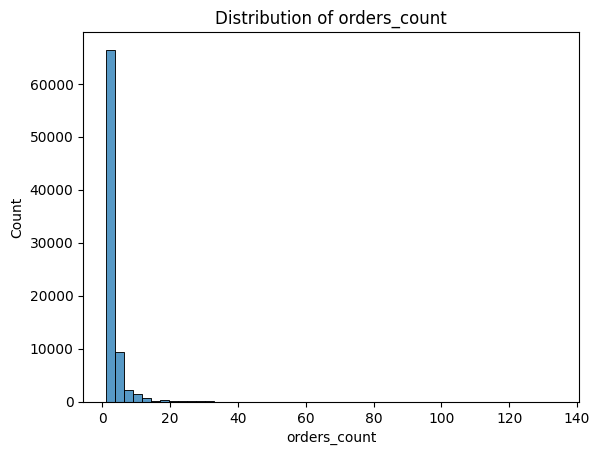

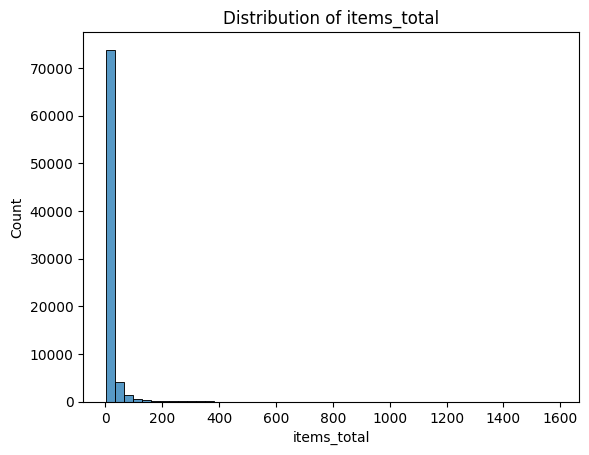

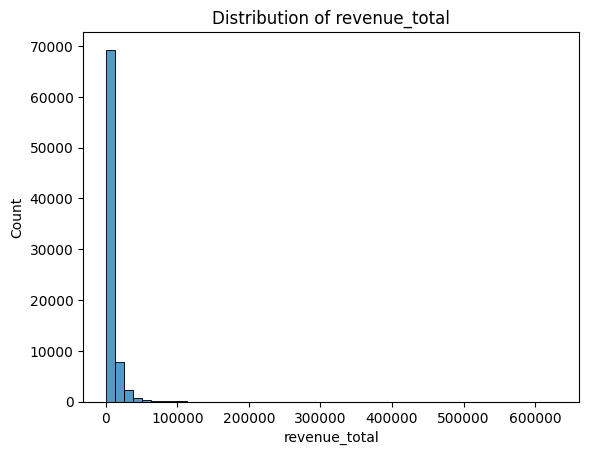

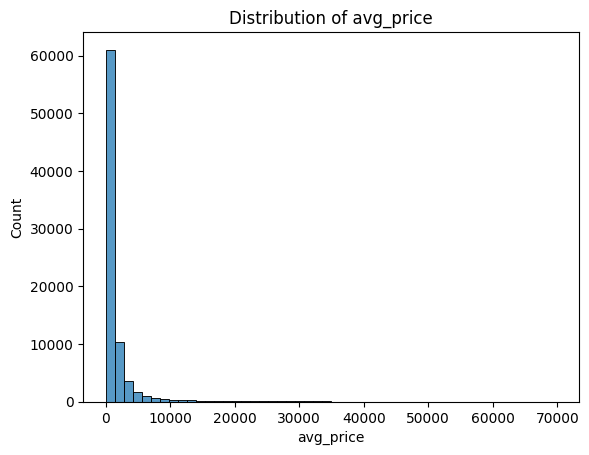

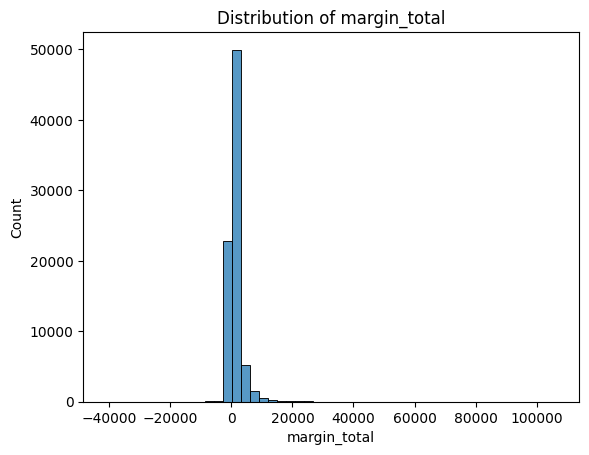

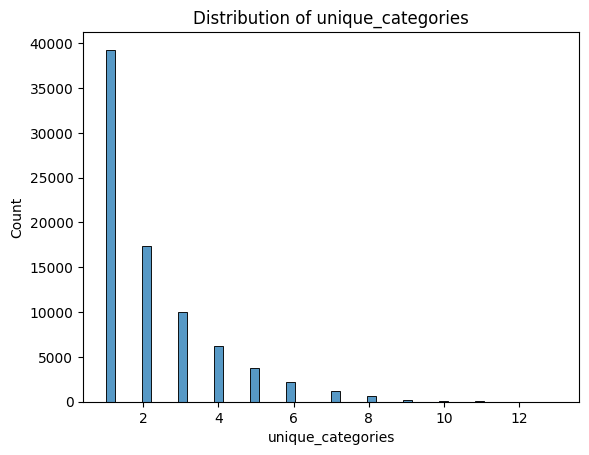

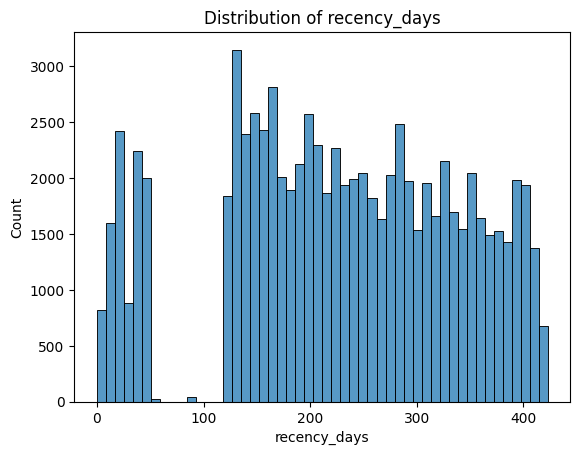

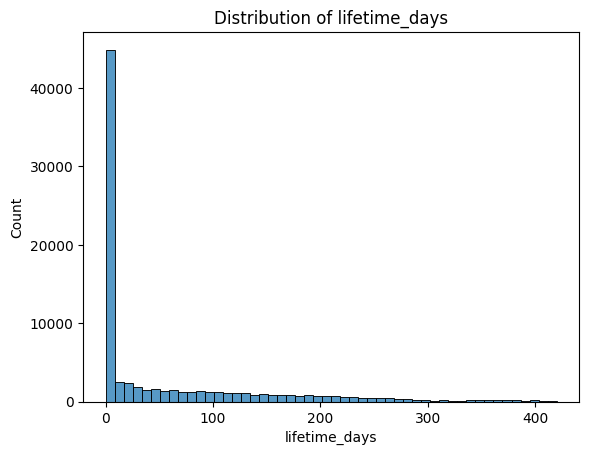

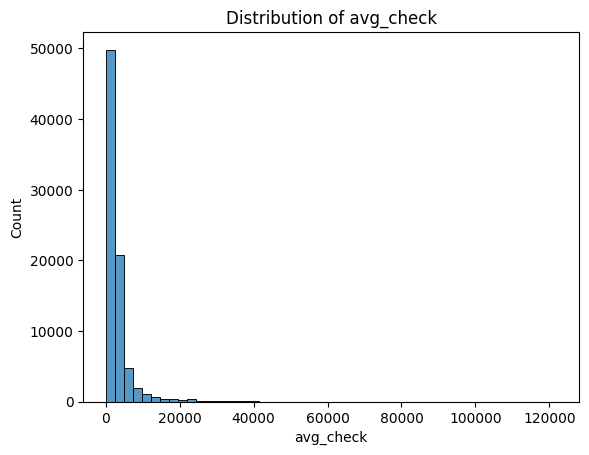

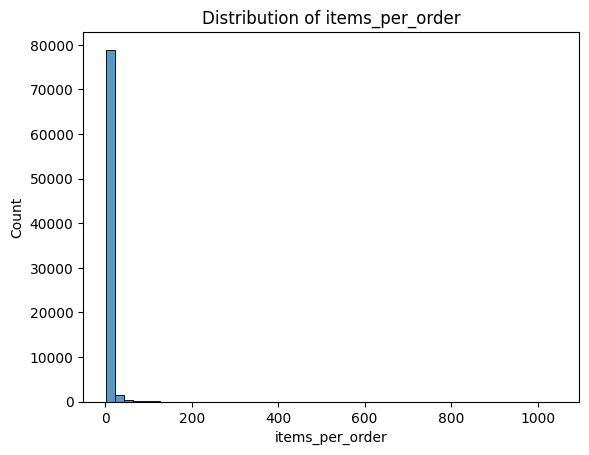

In [312]:
for col in numeric_cols:
    plt.figure()
    sns.histplot(client_df[col], bins=50)
    plt.title(f'Distribution of {col}')
    plt.show()

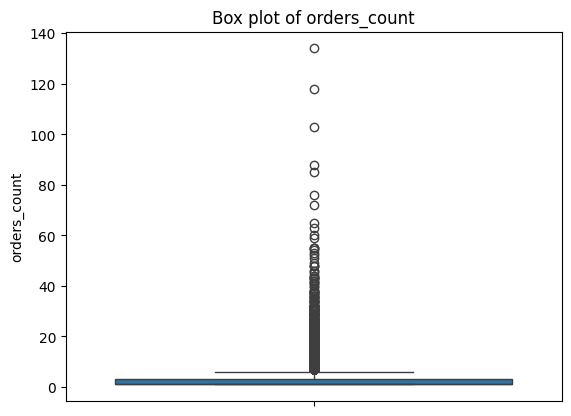

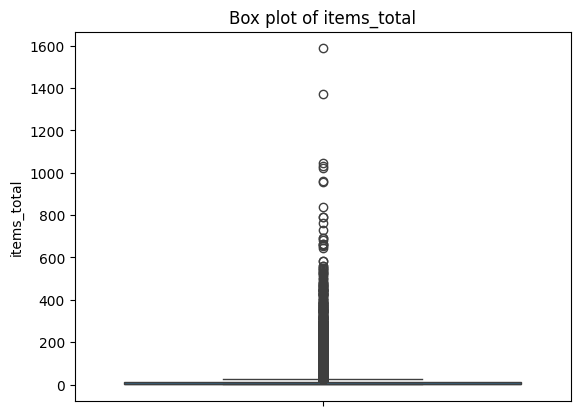

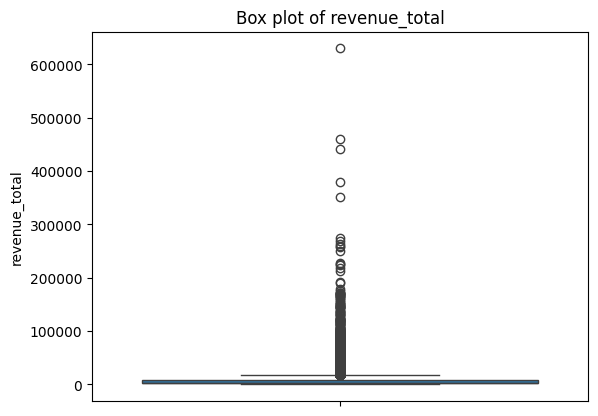

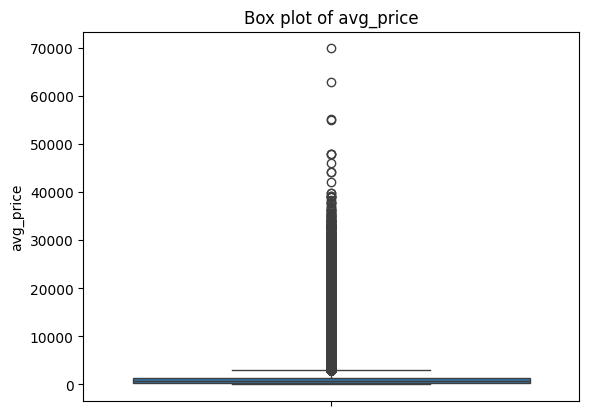

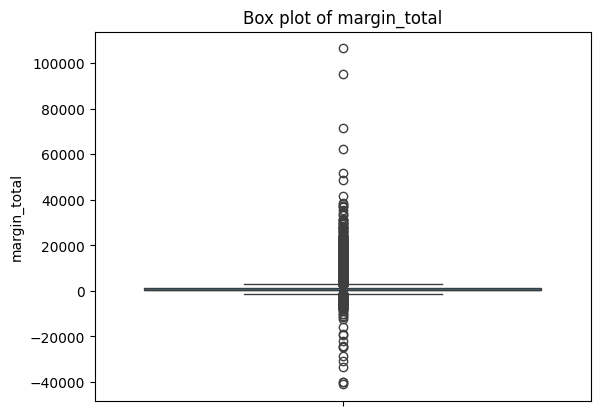

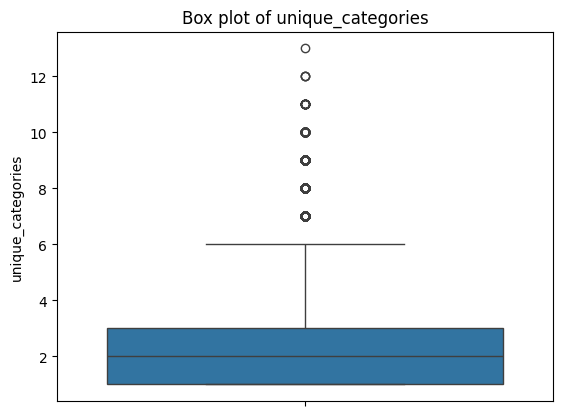

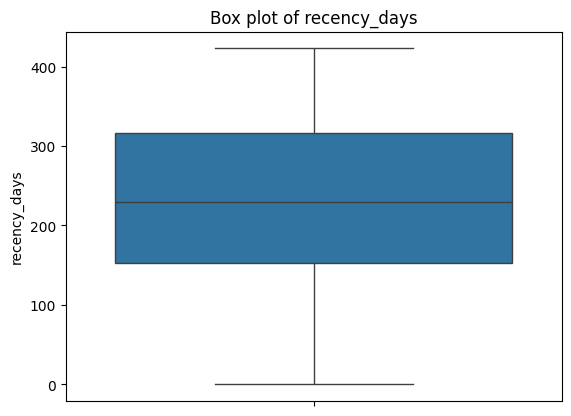

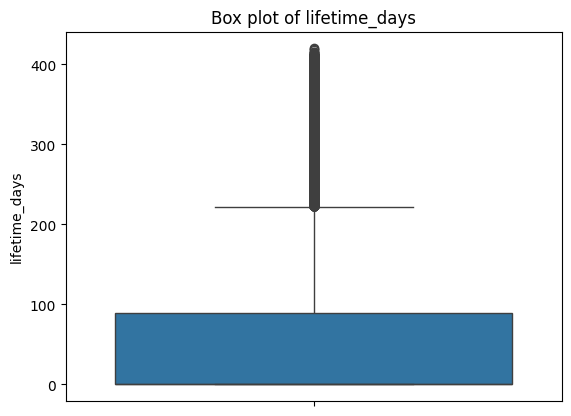

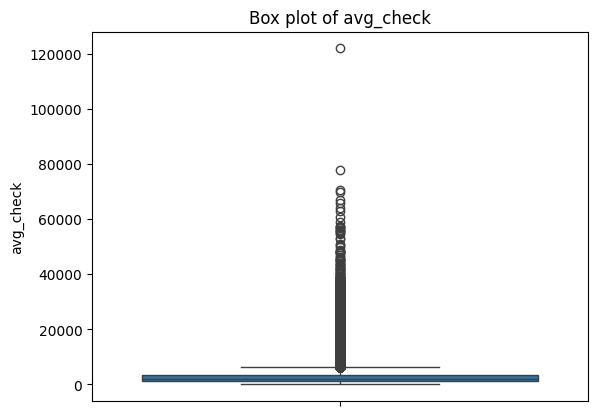

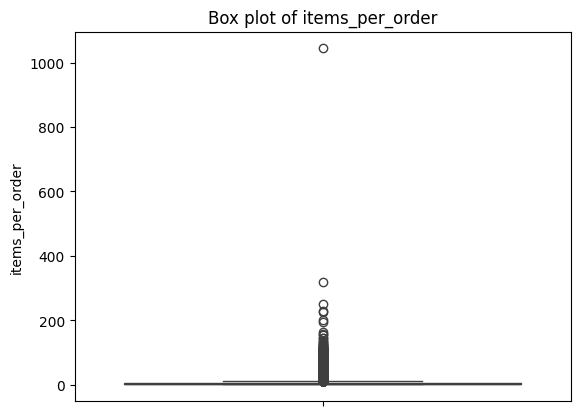

In [313]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(y=client_df[col])  # y для вертикального box plot
    plt.title(f'Box plot of {col}')
    plt.show()

In [314]:
#Логарифмируем колонки
log_cols = [
    'orders_count',
    'revenue_total',
    'items_total',
    'avg_check',
    'avg_price',
    'items_per_order'
]

for col in log_cols:
    client_df[col] = np.log1p(client_df[col])

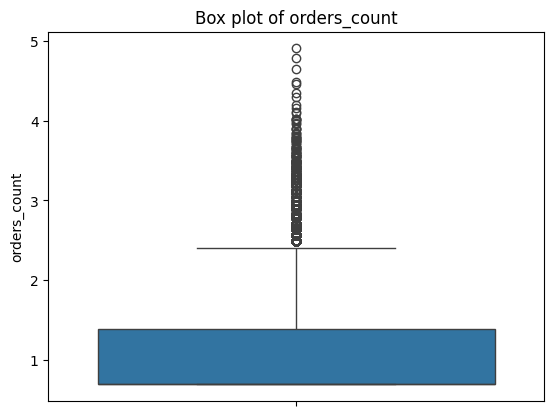

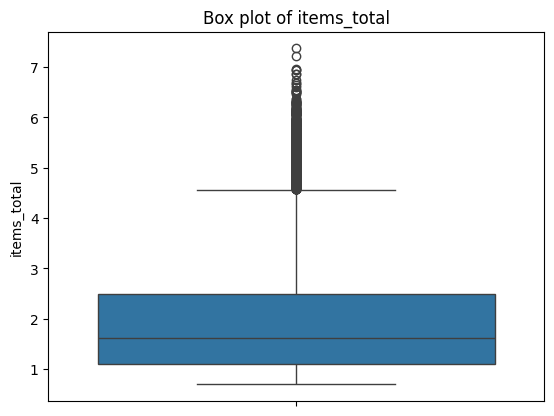

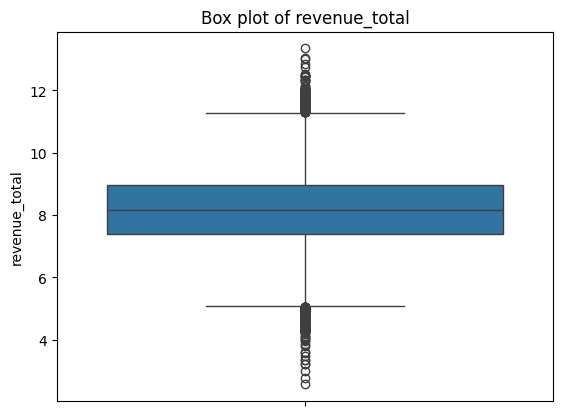

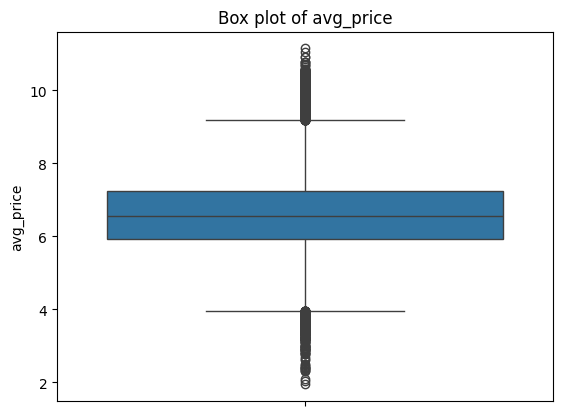

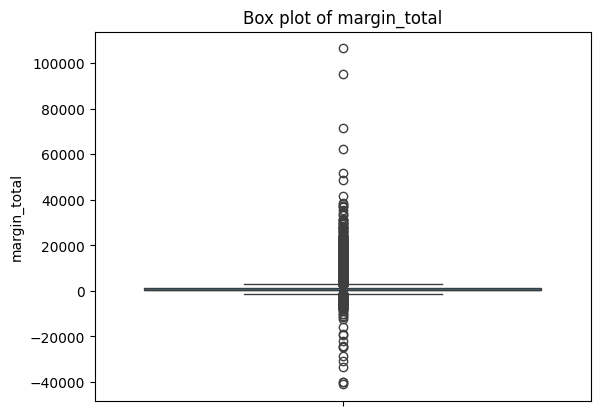

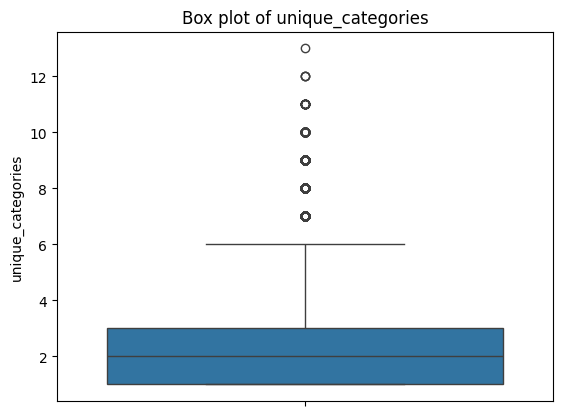

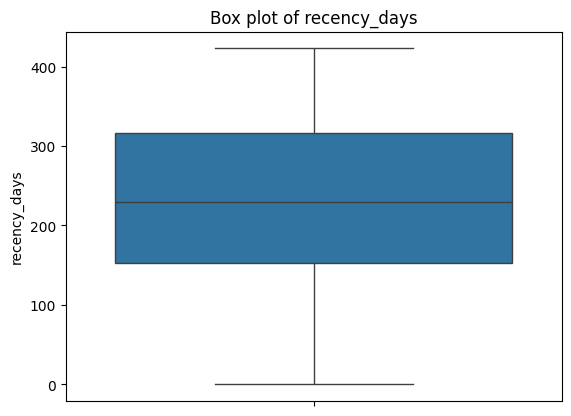

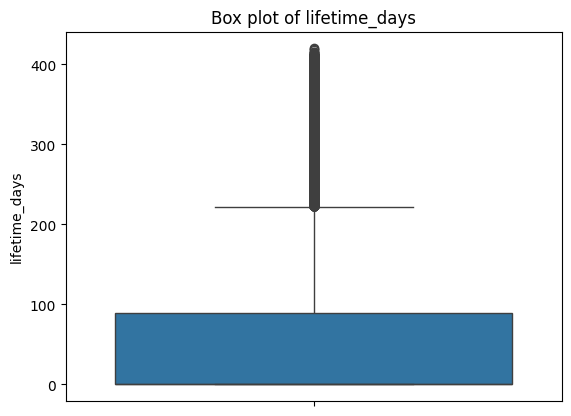

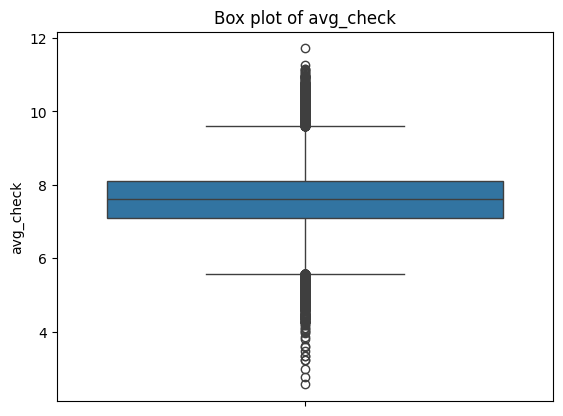

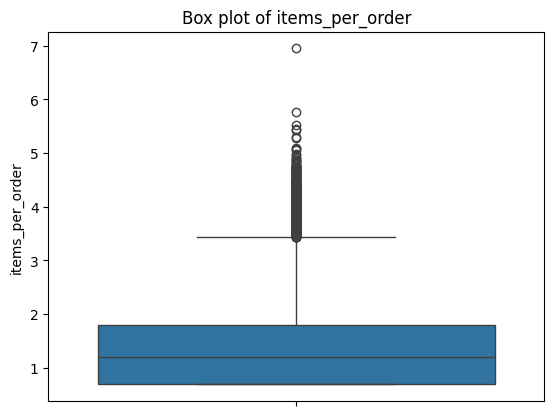

In [315]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(y=client_df[col])  # y для вертикального box plot
    plt.title(f'Box plot of {col}')
    plt.show()

In [316]:
for col in log_cols:
    print(col, client_df[col].min())

orders_count 0.6931471805599453
revenue_total 2.5649493574615367
items_total 0.6931471805599453
avg_check 2.5649493574615367
avg_price 1.9459101490553132
items_per_order 0.6931471805599453


In [317]:
print(client_df[numeric_cols].skew())

orders_count         1.510697
items_total          0.919958
revenue_total       -0.002632
avg_price            0.499824
margin_total           6.3606
unique_categories    1.652426
recency_days        -0.246359
lifetime_days        1.741409
avg_check            0.122679
items_per_order      1.198812
dtype: Float64


In [318]:
client_df['margin_total'].describe(percentiles=[0.5, 0.9, 0.95, 0.99, 0.999])

count     80795.000000
mean       1152.704522
std        2209.551836
min      -41141.360000
50%         513.200000
90%        3075.580000
95%        4781.150000
99%       10011.486000
99.9%     19223.924180
max      106517.640000
Name: margin_total, dtype: float64

In [319]:
#Для margin_total обрежем хвост
lower = client_df['margin_total'].quantile(0.005)
upper = client_df['margin_total'].quantile(0.995)

client_df['margin_total'] = np.clip(
    client_df['margin_total'],
    lower,
    upper
)

In [320]:
client_df['margin_total'].skew()

np.float64(3.025585494784309)

In [321]:
print(client_df['margin_total'].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))
print(f"skew: {client_df['margin_total'].skew():.2f}")

count    80795.000000
mean      1138.064425
std       1887.944383
min      -1828.315100
1%       -1248.500000
5%        -328.969000
50%        513.200000
95%       4781.150000
99%      10011.486000
max      12471.583800
Name: margin_total, dtype: float64
skew: 3.03


In [322]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80795 entries, 0 to 80794
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Телефон_new        80795 non-null  object 
 1   orders_count       80795 non-null  float64
 2   items_total        80795 non-null  Float64
 3   revenue_total      80795 non-null  float64
 4   avg_price          80795 non-null  float64
 5   margin_total       80795 non-null  float64
 6   unique_categories  80795 non-null  int64  
 7   recency_days       80795 non-null  int64  
 8   lifetime_days      80795 non-null  int64  
 9   avg_check          80795 non-null  float64
 10  items_per_order    80795 non-null  Float64
 11  Месяц_Год          80795 non-null  object 
dtypes: Float64(2), float64(5), int64(3), object(2)
memory usage: 7.6+ MB


In [323]:
num_cols = client_df.select_dtypes(include=['int', 'float']).columns

In [324]:
num_cols

Index(['orders_count', 'items_total', 'revenue_total', 'avg_price',
       'margin_total', 'unique_categories', 'recency_days', 'lifetime_days',
       'avg_check', 'items_per_order'],
      dtype='object')

In [325]:
corr_matrix = client_df[num_cols].corr(method='pearson')

corr_matrix.round(2)

,orders_count,items_total,revenue_total,avg_price,margin_total,unique_categories,recency_days,lifetime_days,avg_check,items_per_order
orders_count,1.00,0.75,0.65,-0.16,0.42,0.70,-0.35,0.81,0.05,0.25
items_total,0.75,1.00,0.59,-0.50,0.31,0.75,-0.29,0.61,0.16,0.83
revenue_total,0.65,0.59,1.00,0.39,0.65,0.53,-0.25,0.53,0.79,0.30
avg_price,-0.16,-0.50,0.39,1.00,0.35,-0.28,0.06,-0.12,0.65,-0.60
margin_total,0.42,0.31,0.65,0.35,1.00,0.37,-0.12,0.32,0.53,0.10
unique_categories,0.70,0.75,0.53,-0.28,0.37,1.00,-0.25,0.59,0.13,0.50
recency_days,-0.35,-0.29,-0.25,0.06,-0.12,-0.25,1.00,-0.44,-0.04,-0.13
lifetime_days,0.81,0.61,0.53,-0.12,0.32,0.59,-0.44,1.00,0.05,0.20
avg_check,0.05,0.16,0.79,0.65,0.53,0.13,-0.04,0.05,1.00,0.19
items_per_order,0.25,0.83,0.30,-0.60,0.10,0.50,-0.13,0.20,0.19,1.00


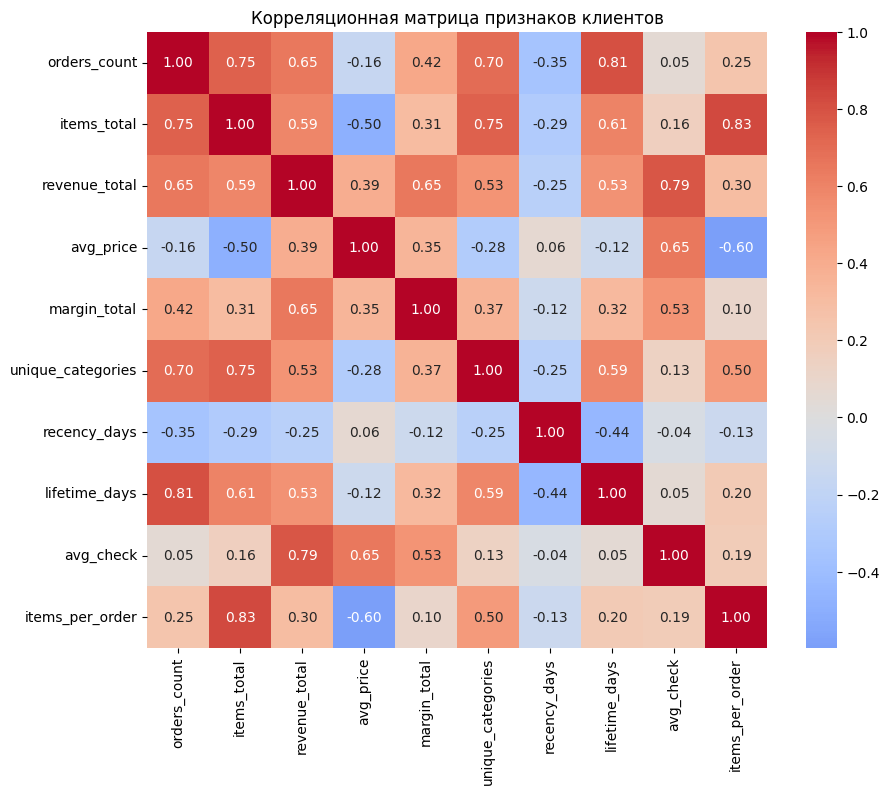

In [326]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Корреляционная матрица признаков клиентов")
plt.show()

In [327]:
features = [
    'orders_count',
    'items_total',
    'revenue_total',
    'avg_price',
    'margin_total',
    'unique_categories',
    'recency_days',
    'lifetime_days',
    'avg_check',
    'items_per_order'
]

In [328]:
X = client_df[features].copy()

In [329]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

In [330]:
X_kmeans = X_scaled.copy()
X_em = X_scaled.copy()
X_hdbscan = X_scaled.copy()

In [181]:
inertia = []
ch_scores = []
db_scores = []

K_range = range(2, 20)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_kmeans)

    inertia.append(kmeans.inertia_)

    ch_scores.append(
        calinski_harabasz_score(X_kmeans, labels)
    )

    db_scores.append(
        davies_bouldin_score(X_kmeans, labels)
    )

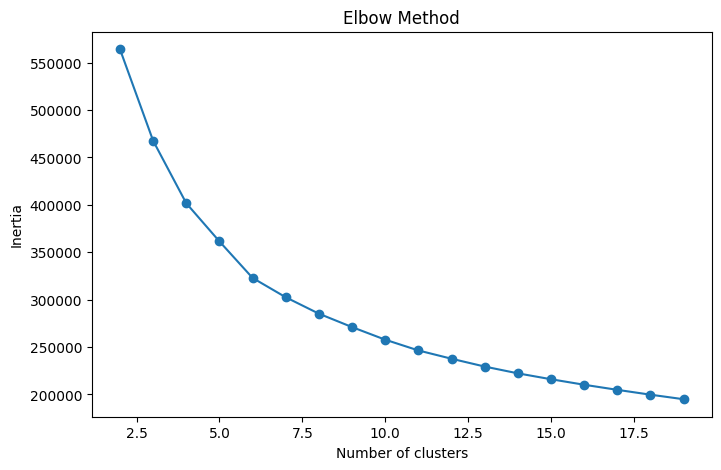

In [182]:
#метод локтя
plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker='o')

plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

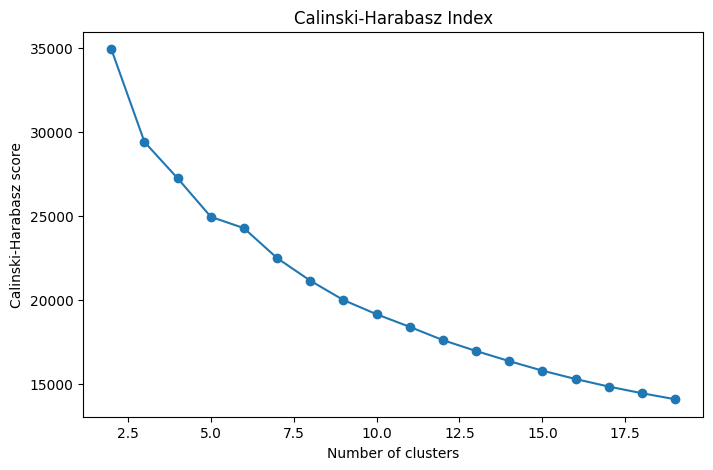

In [183]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, ch_scores, marker='o')

plt.xlabel('Number of clusters')
plt.ylabel('Calinski-Harabasz score')
plt.title('Calinski-Harabasz Index')

plt.show()

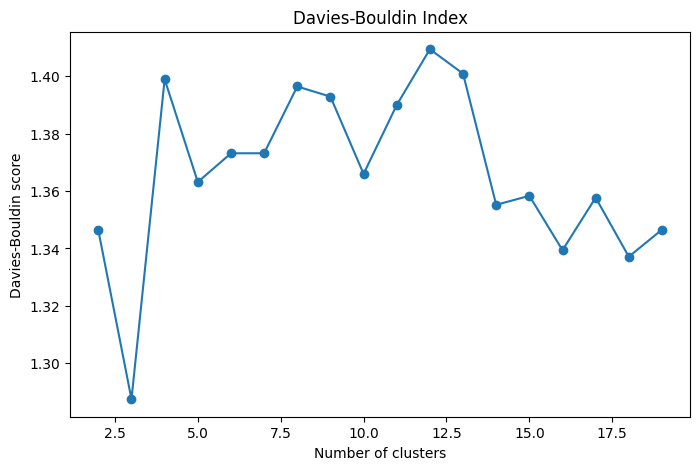

In [184]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, db_scores, marker='o')

plt.xlabel('Number of clusters')
plt.ylabel('Davies-Bouldin score')
plt.title('Davies-Bouldin Index')

plt.show()

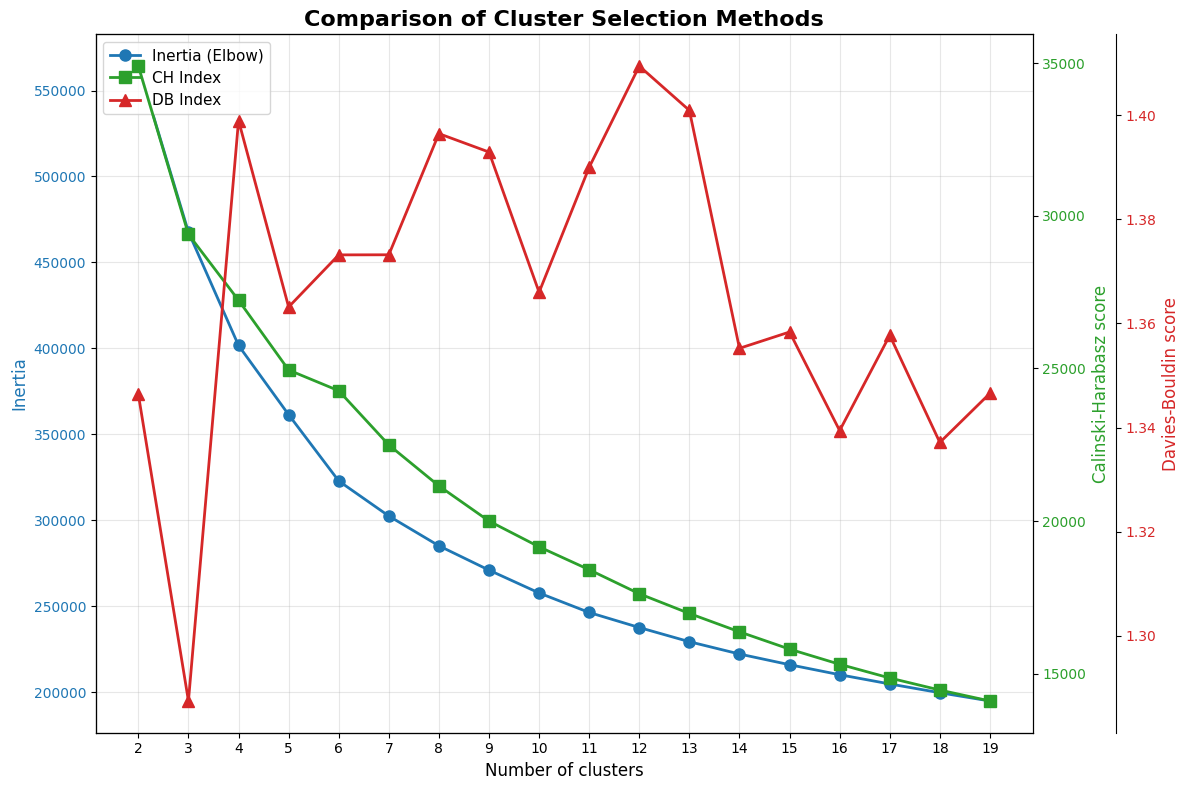

In [185]:
fig, ax1 = plt.subplots(figsize=(12, 8))
ax1.set_xticks(K_range)
color = 'tab:blue'
ax1.set_xlabel('Number of clusters', fontsize=12)
ax1.set_ylabel('Inertia', color=color, fontsize=12)
line1 = ax1.plot(K_range, inertia, marker='o', color=color, linewidth=2, markersize=8, label='Inertia (Elbow)')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Calinski-Harabasz score', color=color, fontsize=12)
line2 = ax2.plot(K_range, ch_scores, marker='s', color=color, linewidth=2, markersize=8, label='CH Index')
ax2.tick_params(axis='y', labelcolor=color)

ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
color = 'tab:red'
ax3.set_ylabel('Davies-Bouldin score', color=color, fontsize=12)
line3 = ax3.plot(K_range, db_scores, marker='^', color=color, linewidth=2, markersize=8, label='DB Index')
ax3.tick_params(axis='y', labelcolor=color)

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=11)

plt.title('Comparison of Cluster Selection Methods', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [187]:
metrics_df = pd.DataFrame({
    'k': list(K_range),
    'inertia': inertia,
    'calinski_harabasz': ch_scores,
    'davies_bouldin': db_scores
})

metrics_df

,k,inertia,calinski_harabasz,davies_bouldin
0,2,564215.863878,34901.630498,1.346349
1,3,467683.666255,29390.461897,1.287474
2,4,401719.057302,27232.919797,1.398977
3,5,361464.734167,24948.260794,1.363155
4,6,322919.822457,24269.296966,1.373164
5,7,302531.987183,22494.490147,1.373182
6,8,285208.863684,21152.827320,1.396455
7,9,271056.307640,20002.110912,1.392916
8,10,257772.559892,19158.223549,1.365986
9,11,246421.404523,18408.562146,1.389993


* Davies-Bouldin - 2-е минимальное значение при k=7
* Elbow method - после 7 снижение инерции замедляется
* Calinski-Harabasz - хотя пик при k=2, после 7 падение стабилизируется

Исходя из этого, оптимальным выбором будет k=7

# K-means

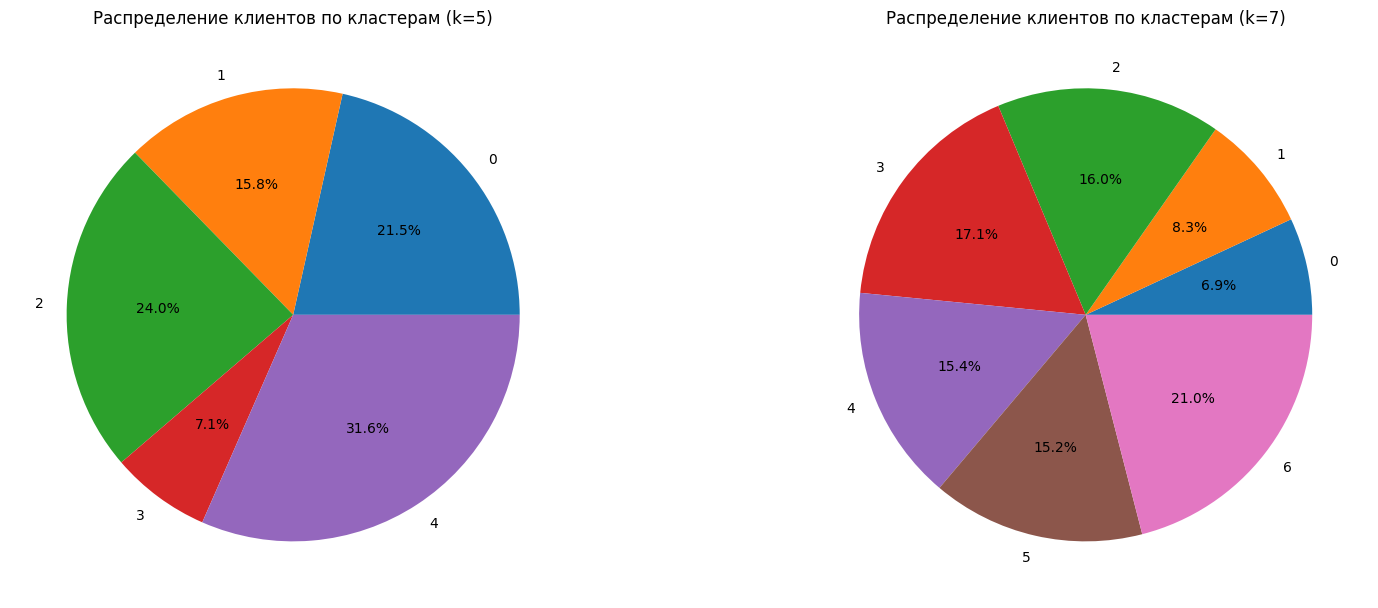

In [331]:
k_values = [5, 7]

plt.figure(figsize=(16, 12))

for i, k in enumerate(k_values, 1):
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_kmeans)
    
    cluster_counts = (
        pd.Series(clusters)
        .value_counts()
        .sort_index()
    )
    
    client_df[f'cluster_{k}'] = clusters
    plt.subplot(2, 2, i)
    plt.pie(
        cluster_counts.values,
        labels=cluster_counts.index,
        autopct='%1.1f%%'
    )
    
    plt.title(f'Распределение клиентов по кластерам (k={k})')

plt.tight_layout()
plt.show()

In [191]:
for k in [5, 6, 7]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_kmeans)
    sil = silhouette_score(X_kmeans, labels)
    print(f"k={k}: silhouette = {sil:.4f}")

k=5: silhouette = 0.2011
k=6: silhouette = 0.2104
k=7: silhouette = 0.2002



Распределение по кластерам (k=4)
Кластер    Кол-во     Доля, %   
------------------------------
0          12092      15.0      
1          24695      30.6      
2          12198      15.1      
3          31810      39.4      

Распределение по кластерам (k=5)
Кластер    Кол-во     Доля, %   
------------------------------
0          17368      21.5      
1          12768      15.8      
2          19387      24.0      
3          5764       7.1       
4          25508      31.6      

Распределение по кластерам (k=7)
Кластер    Кол-во     Доля, %   
------------------------------
0          5600       6.9       
1          6742       8.3       
2          12952      16.0      
3          13853      17.1      
4          12430      15.4      
5          12266      15.2      
6          16952      21.0      


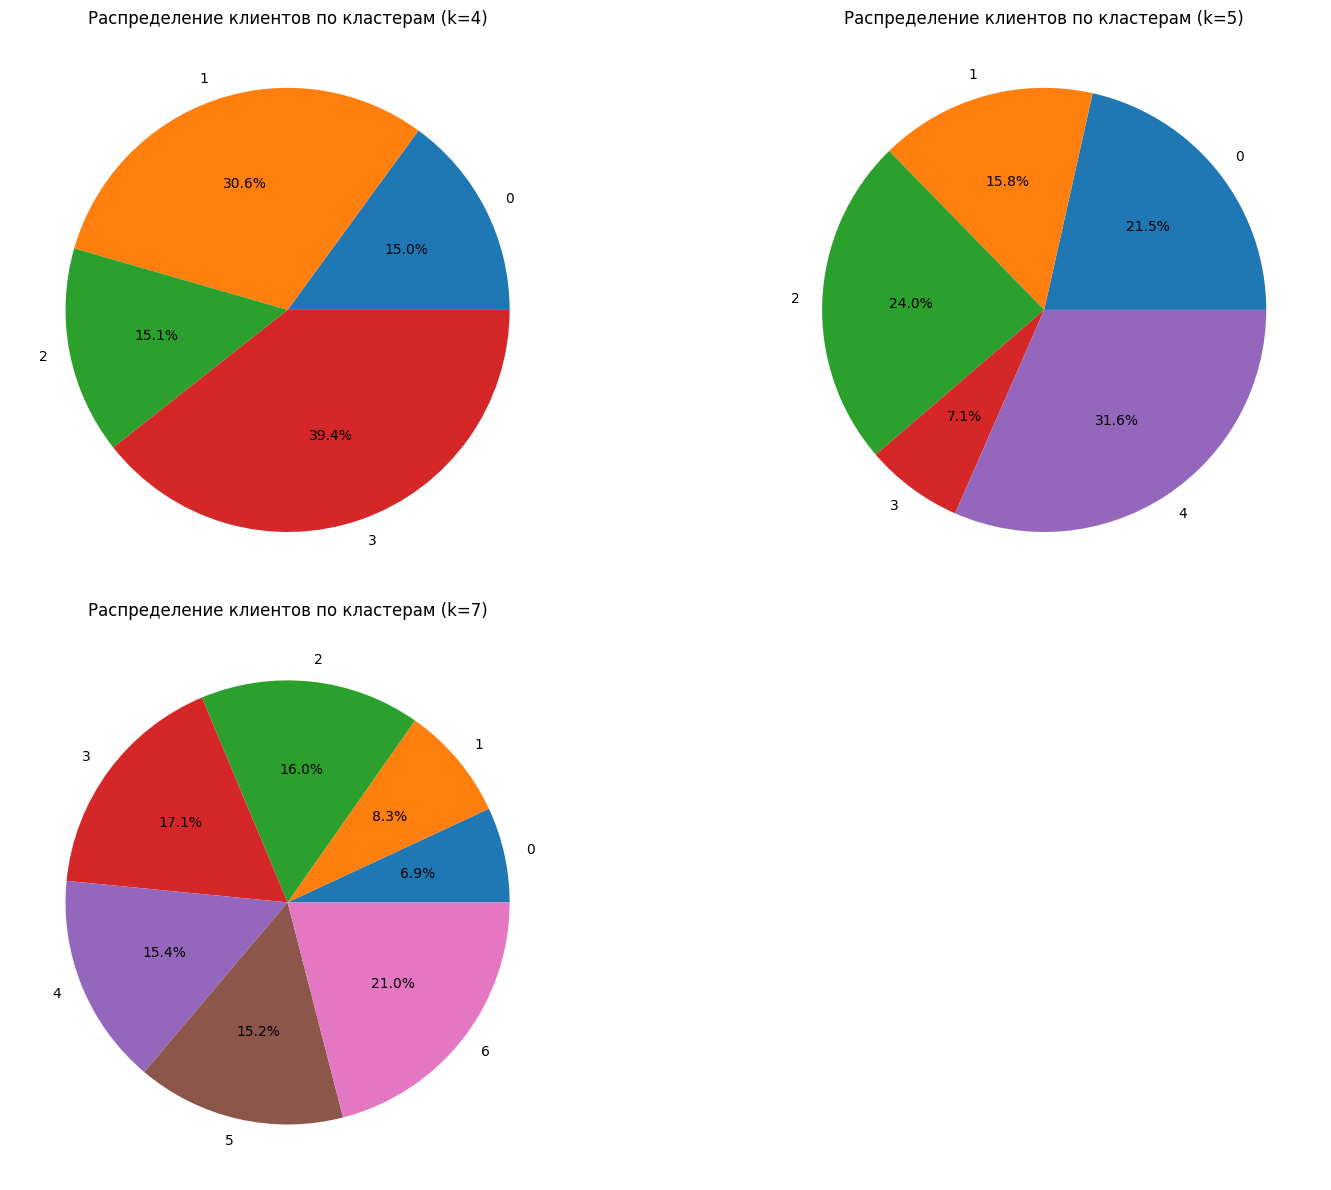

In [332]:
k_values = [4, 5, 7]

plt.figure(figsize=(16, 12))

for i, k in enumerate(k_values, 1):
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_kmeans)
    
    cluster_counts = (
        pd.Series(clusters)
        .value_counts()
        .sort_index()
    )
    
    client_df[f'cluster_{k}'] = clusters
    
    # Таблица с процентами
    cluster_percent = (
        cluster_counts / cluster_counts.sum() * 100
    ).round(1)
    
    print(f"\n{'='*40}")
    print(f"Распределение по кластерам (k={k})")
    print(f"{'='*40}")
    print(f"{'Кластер':<10} {'Кол-во':<10} {'Доля, %':<10}")
    print(f"{'-'*30}")
    for cluster_id in sorted(cluster_percent.index):
        print(f"{cluster_id:<10} {cluster_counts[cluster_id]:<10} {cluster_percent[cluster_id]:<10}")
    print(f"{'='*40}")
    
    plt.subplot(2, 2, i)
    plt.pie(
        cluster_counts.values,
        labels=cluster_counts.index,
        autopct='%1.1f%%'
    )
    
    plt.title(f'Распределение клиентов по кластерам (k={k})')

plt.tight_layout()
plt.show()

In [333]:
#Составим портрет кластеров
def cluster_profile(df, features, cluster_col):
    
    # агрегаты по признакам
    profile = df.groupby(cluster_col)[features].agg(['mean', 'median']).round(2)
    
    # количество клиентов
    counts = df[cluster_col].value_counts().sort_index()
    total = len(df)
    
    # процент от общего числа
    share = (counts / total * 100).round(2)
    
    # добавляем в таблицу
    profile[('cluster_size', 'count')] = counts
    profile[('cluster_size', 'share_%')] = share
    
    return profile

In [194]:
cluster_col = 'cluster_7'

profile_7 = cluster_profile(client_df, features, cluster_col)

display(profile_7)

orders_count        items_total        revenue_total         \
                  mean median        mean median          mean median   
cluster_7                                                               
0                 0.89   0.69        1.18    1.1          9.65   9.63   
1                 2.16   2.08        3.93   3.83          9.95   9.92   
2                 0.77   0.69        1.16    1.1          6.51   6.58   
3                 1.54   1.61        2.45    2.4          8.85   8.87   
4                 0.96   0.69        2.78   2.64          8.25   8.23   
5                 0.82   0.69        1.19    1.1          7.69   7.65   
6                 0.80   0.69        1.11    1.1          7.98   7.96   

          avg_price        margin_total           ... recency_days         \
               mean median         mean   median  ...         mean median   
cluster_7                                         ...                       
0              8.96   8.96      4600.79  3762.32  ...       245.58  253.0   
1              6.18   6.15      3915.99  3164.16  ...       131.92  141.0   
2              5.81   5.87       163.71   142.90  ...       282.65  289.0   
3              6.54   6.54      1096.59   949.58  ...       170.39  172.0   
4              5.65   5.71       721.05   549.13  ...       247.63  253.0   
5              6.93   6.90       320.40   266.00  ...       126.27  146.0   
6              7.34   7.26       565.12   470.56  ...       325.38  330.0   

          lifetime_days        avg_check        items_per_order         \
                   mean median      mean median            mean median   
cluster_7                                                                
0                 22.35    0.0      9.34   9.29            0.95   0.69   
1                217.59  214.0      7.93   7.91            2.06   1.98   
2                  7.35    0.0      6.39   6.47            1.06    1.1   
3                152.70  143.0      7.56   7.59            1.38   1.39   
4                 25.11    2.0      7.82   7.79            2.39   2.25   
5                 14.36    0.0      7.47   7.44            1.03    1.1   
6                 10.01    0.0      7.80   7.76            0.98   0.92   

          cluster_size          
                 count share_%  
cluster_7                       
0                 5600    6.93  
1                 6742    8.34  
2                12952   16.03  
3                13853   17.15  
4                12430   15.38  
5                12266   15.18  
6                16952   20.98  

[7 rows x 22 columns]

In [349]:
cluster_col = 'cluster_5'

profile_5 = cluster_profile(client_df, features, cluster_col)

display(profile_5)

orders_count        items_total        revenue_total         \
                  mean median        mean median          mean median   
cluster_5                                                               
0                 0.77   0.69        1.13    1.1          6.66   6.78   
1                 1.96   1.95        3.38    3.3          9.56   9.53   
2                 1.07   1.10        2.61   2.48          8.33   8.33   
3                 0.90   0.69         1.2    1.1          9.65   9.63   
4                 0.87   0.69        1.16    1.1          8.05   8.01   

          avg_price        margin_total           ... recency_days         \
               mean median         mean   median  ...         mean median   
cluster_5                                         ...                       
0              5.99   6.05       176.36   150.04  ...       259.65  272.0   
1              6.33   6.33      2724.01  2032.14  ...       136.72  145.0   
2              5.89   5.95       728.88   586.87  ...       229.76  232.0   
3              8.93   8.94      4604.61  3750.00  ...       248.39  258.0   
4              7.33   7.26       526.70   443.90  ...       246.48  256.0   

          lifetime_days        avg_check        items_per_order         \
                   mean median      mean median            mean median   
cluster_5                                                                
0                  8.93    0.0      6.53   6.64            1.04   0.92   
1                206.73  201.0      7.78   7.77            1.78   1.68   
2                 46.41   23.0      7.72   7.69            2.07   1.95   
3                 25.14    0.0      9.32   9.26            0.96   0.69   
4                 24.36    0.0      7.77   7.73            0.96   0.92   

          cluster_size          
                 count share_%  
cluster_5                       
0                17368   21.50  
1                12768   15.80  
2                19387   24.00  
3                 5764    7.13  
4                25508   31.57  

[5 rows x 22 columns]

In [350]:
# Выводим профиль кластеров в читаемом виде
profile_df = profile_5.copy()

# Объединяем мультииндекс в плоские названия колонок
profile_df.columns = ['_'.join(col).strip() for col in profile_df.columns.values]

# Округляем
profile_df = profile_df.round(3)

# Выводим как CSV-строку (можно скопировать)
print(profile_df.to_csv(sep=';'))

cluster_5;orders_count_mean;orders_count_median;items_total_mean;items_total_median;revenue_total_mean;revenue_total_median;avg_price_mean;avg_price_median;margin_total_mean;margin_total_median;unique_categories_mean;unique_categories_median;recency_days_mean;recency_days_median;lifetime_days_mean;lifetime_days_median;avg_check_mean;avg_check_median;items_per_order_mean;items_per_order_median;cluster_size_count;cluster_size_share_%
0;0.77;0.69;1.13;1.1;6.66;6.78;5.99;6.05;176.36;150.04;1.26;1.0;259.65;272.0;8.93;0.0;6.53;6.64;1.04;0.92;17368;21.5
1;1.96;1.95;3.38;3.3;9.56;9.53;6.33;6.33;2724.01;2032.14;4.57;4.0;136.72;145.0;206.73;201.0;7.78;7.77;1.78;1.68;12768;15.8
2;1.07;1.1;2.61;2.48;8.33;8.33;5.89;5.95;728.88;586.87;2.73;3.0;229.76;232.0;46.41;23.0;7.72;7.69;2.07;1.95;19387;24.0
3;0.9;0.69;1.2;1.1;9.65;9.63;8.93;8.94;4604.61;3750.0;1.55;1.0;248.39;258.0;25.14;0.0;9.32;9.26;0.96;0.69;5764;7.13
4;0.87;0.69;1.16;1.1;8.05;8.01;7.33;7.26;526.7;443.9;1.34;1.0;246.48;256.0;24.36;0.0;7.77

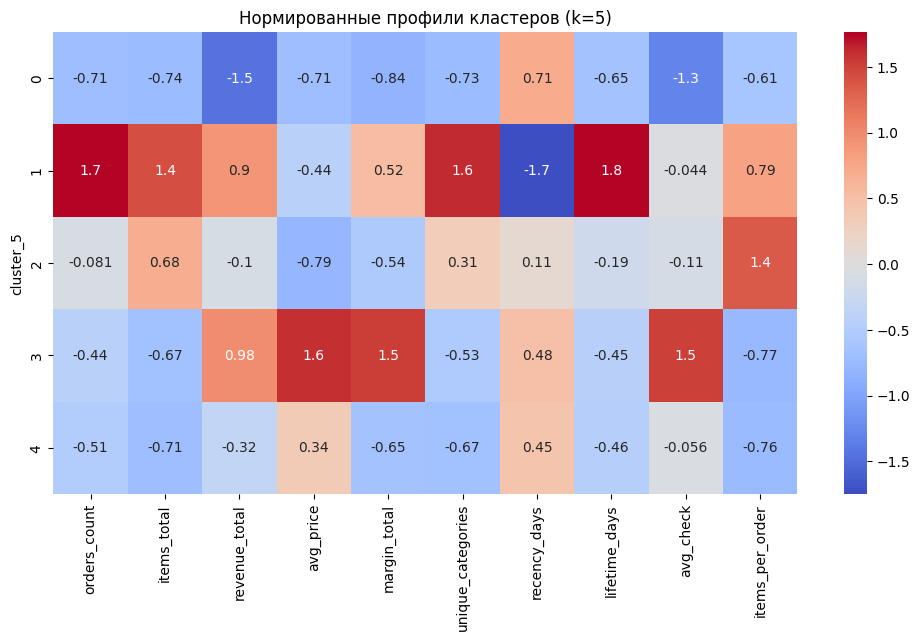

In [351]:
means = client_df.groupby('cluster_5')[features].mean().astype(float)

means_scaled = (means - means.mean()) / means.std()

plt.figure(figsize=(12,6))
sns.heatmap(means_scaled, annot=True, cmap="coolwarm", center=0)
plt.title("Нормированные профили кластеров (k=5)")
plt.show()

In [194]:
result = client_df.groupby('cluster_7')[features].mean().astype(float).round(2)
result['%_клиентов'] = (client_df['cluster_7'].value_counts(normalize=True) * 100).round(2).sort_index()
result.to_excel('clusters_with_pct.xlsx')

* ordes_count — количество заказов
* items_per_order — товаров в заказе
* revenue_total — общая выручка
* avg_price — средний чек / цена
* margin_total — общая маржинальность
* unique_categories — уникальных категорий
* recent_days — давность последней покупки (чем меньше, тем лучше / активнее)
* lifetime_days — длительность жизни клиента

*Кластер 0 — «Потерянные клиенты» (21.5%)*

Все показатели значительно ниже среднего. Минимальная выручка (–1.5), низкая маржа (–0.84) и количество категорий (–0.73). Высокая давность (0.71) — давно не покупали. Низкий средний чек (–1.3) и мало товаров в заказе (–0.61). Практически не взаимодействуют с магазином, а те покупки, что были — незначительны по объёму. Кандидаты на полный отток.

*Кластер 1 — «Активные лояльные клиенты» (15.8%)*

Лидеры по частоте заказов (1.7) и количеству категорий (1.6). Высокая суммарная выручка (0.9) и объём товаров (1.4). Минимальная давность (–1.7) — покупают прямо сейчас. Максимальная продолжительность жизни (1.8) — с магазином давно. Средняя цена ниже среднего (–0.44) — высокая выручка достигается за счёт объёма и частоты, а не дорогих товаров. Ядро аудитории с насыщенной историей.

*Кластер 2 — «Эпизодические с большим количеством товаров» (24.0%)*

Главная особенность — максимальное количество товаров в заказе (1.4). Объём товаров выше среднего (0.68), частота заказов около среднего (–0.08). Выручка близка к средней (–0.1). Средняя цена ниже среднего (–0.79) — берут много недорогих позиций за раз. Давность около средней (0.11). Клиенты, которые покупают время от времени, но основательно.

*Кластер 3 — «VIP-дорогие клиенты» (7.1%)*

Максимальная средняя цена (1.6) и маржинальность (1.5). Выручка выше среднего (0.98), при этом частота заказов ниже среднего (–0.44). Средний чек максимальный (1.5). Давность выше средней (0.48) — покупают не часто и не совсем недавно. Узкий ассортимент (–0.53 категорий). Немногочисленный, но ценный сегмент: дорогие товары, высокая маржа, редкие покупки.

*Кластер 4 — «Спящие клиенты» (31.6%)*

Самый многочисленный сегмент. Все показатели активности ниже среднего: частота заказов (–0.51), объём товаров (–0.71), выручка (–0.32), маржа (–0.65), число категорий (–0.67). Давность выше средней (0.45) — давно не покупали. Средняя цена чуть выше среднего (0.34). Клиенты, которые когда-то покупали, но перестали возвращаться. Близки к состоянию холодного старта.

**Итог**
* Потерянные клиенты (21.5%) - 0
* Активные лояльные (15.8%) - 1
* Эпизодические с большим количеством товаров (24.0%) - 2
* VIP-дорогие (7.1%) - 3
* Спящие клиенты (31.6%) - 4

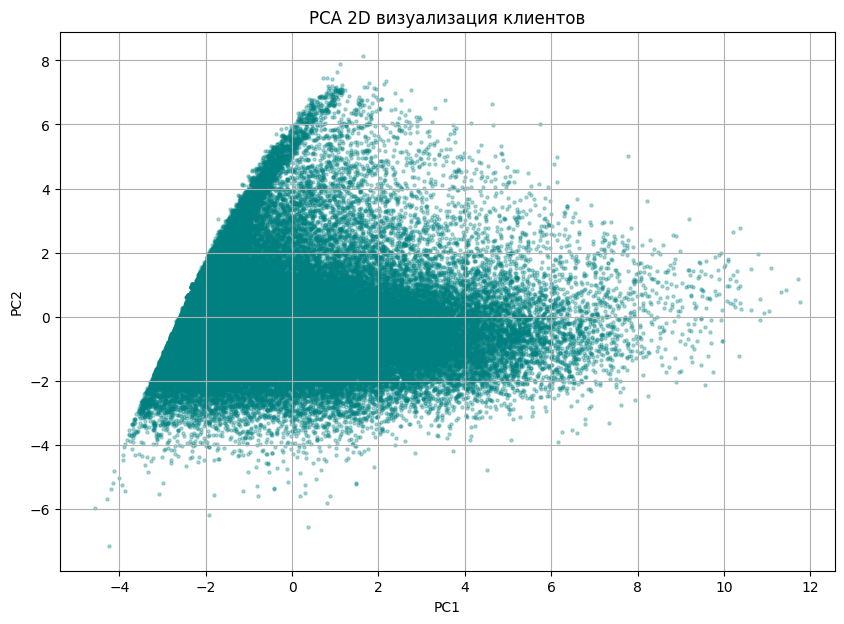

Доля объясненной дисперсии: PC1 = 0.45, PC2 = 0.25, PC1+PC2 = 0.70


In [200]:
#PCA
X_plot = X_kmeans.copy() 
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_plot)
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Визуализация
plt.figure(figsize=(10, 7))
plt.scatter(pca_df['PC1'], pca_df['PC2'], s=5, alpha=0.3, color='teal')
plt.title('PCA 2D визуализация клиентов')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.show()

explained_var = pca.explained_variance_ratio_
print(f"Доля объясненной дисперсии: PC1 = {explained_var[0]:.2f}, PC2 = {explained_var[1]:.2f}, PC1+PC2 = {explained_var[0]+explained_var[1]:.2f}")

# HDBSCAN


Распределение клиентов по кластерам (HDBSCAN):
cluster_hdbscan
-1    29660
 0    21119
 1     1393
 2    15364
 3      789
 4     4091
 5     3454
 6     4925
Name: count, dtype: int64
Процент клиентов, относящихся к шуму: 36.71%


/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_37946/2113261620.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='cluster_hdbscan', data=client_clusters, palette='tab10', order=cluster_counts.index)


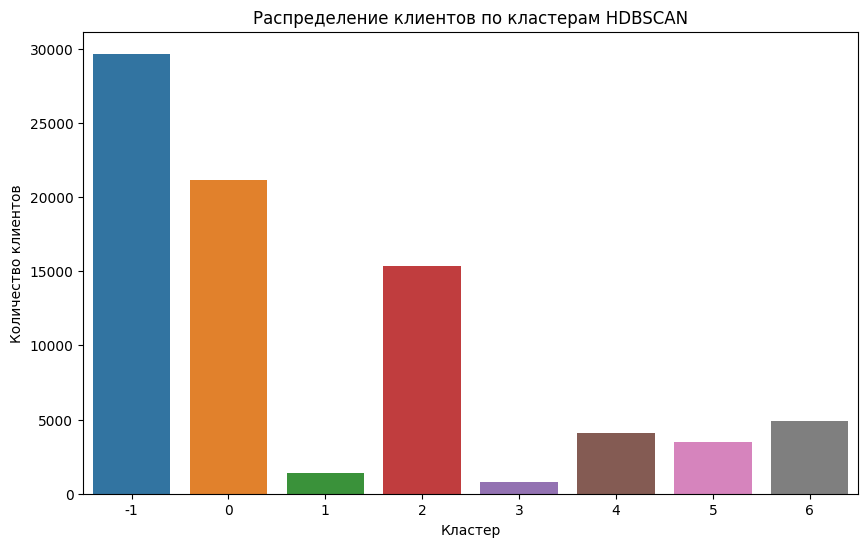

In [202]:
# Настройка HDBSCAN
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=500,   # минимальный размер кластера
    min_samples=50,         # чувствительность к шуму
    metric='euclidean',
    cluster_selection_method='eom'
)

# Обучаем модель
cluster_labels = clusterer.fit_predict(X_hdbscan)

# Добавляем метки в датафрейм клиентов
client_clusters = client_df.copy()
client_clusters['cluster_hdbscan'] = cluster_labels

# Посмотрим распределение по кластерам
cluster_counts = client_clusters['cluster_hdbscan'].value_counts().sort_index()
print("Распределение клиентов по кластерам (HDBSCAN):")
print(cluster_counts)

# Процент клиентов, которые HDBSCAN считает шумом (-1)
noise_pct = (cluster_counts.get(-1, 0) / len(client_clusters)) * 100
print(f"Процент клиентов, относящихся к шуму: {noise_pct:.2f}%")

# Визуализация распределения кластеров
plt.figure(figsize=(10,6))
sns.countplot(x='cluster_hdbscan', data=client_clusters, palette='tab10', order=cluster_counts.index)
plt.title('Распределение клиентов по кластерам HDBSCAN')
plt.xlabel('Кластер')
plt.ylabel('Количество клиентов')
plt.show()

/Users/ekaterinazinoveva/Mag/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


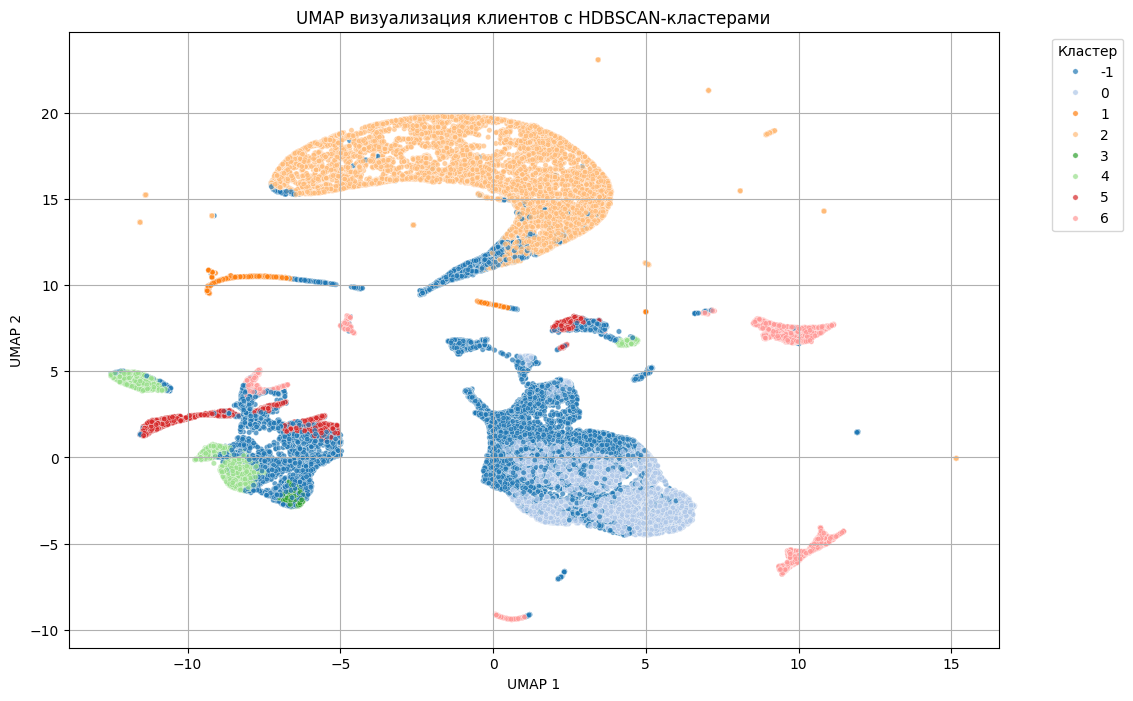

In [203]:
X_umap = X_scaled.copy() 

# UMAP
reducer = umap.UMAP(
    n_components=2, 
    n_neighbors=50,       
    min_dist=0.0,         
    metric='euclidean', 
    random_state=42
)
X_embedded = reducer.fit_transform(X_umap)

umap_df = pd.DataFrame(X_embedded, columns=['UMAP1', 'UMAP2'])
umap_df['cluster'] = client_clusters['cluster_hdbscan'].values

plt.figure(figsize=(12,8))
palette = sns.color_palette("tab20", n_colors=len(umap_df['cluster'].unique()))
sns.scatterplot(
    x='UMAP1', y='UMAP2', 
    hue='cluster', 
    data=umap_df, 
    palette=palette,
    legend='full',
    s=15,
    alpha=0.7
)
plt.title('UMAP визуализация клиентов с HDBSCAN-кластерами')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.legend(title='Кластер', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()

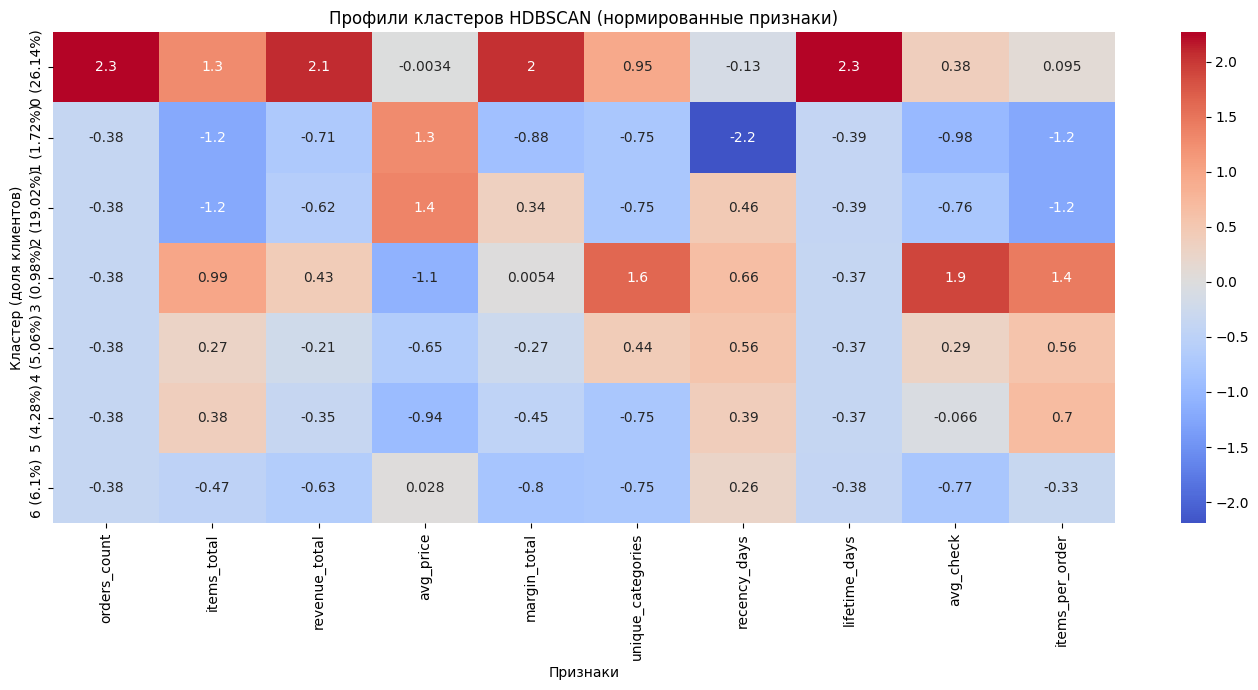

In [204]:
# убираем шум
df_hdb = client_clusters[client_clusters['cluster_hdbscan'] != -1].copy()

# средние значения
means_hdb = df_hdb.groupby('cluster_hdbscan')[features].mean().astype(float)

# нормализация ПО СТОЛБЦАМ
means_scaled = (means_hdb - means_hdb.mean()) / means_hdb.std()

# доля клиентов (без шума)
cluster_sizes = df_hdb['cluster_hdbscan'].value_counts().sort_index()
cluster_share = (cluster_sizes / len(client_clusters) * 100).round(2)

# добавляем % в название кластера
new_index = [
    f"{cluster} ({cluster_share[cluster]}%)"
    for cluster in means_scaled.index
]

means_scaled.index = new_index

plt.figure(figsize=(14, 7))

sns.heatmap(
    means_scaled,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Профили кластеров HDBSCAN (нормированные признаки)")
plt.xlabel("Признаки")
plt.ylabel("Кластер (доля клиентов)")
plt.tight_layout()
plt.show()

Кластер 0 (22,06%) имеет максимальные значения по количеству заказов (+3,61) и длительности жизни клиента (+3,61). Кластер 1 (0,54%) показывает наибольшую широту категорий (+2,69) и количество товаров в заказе (+1,83). Кластер 5 (9,63%) лидирует по среднему чеку (+2,43) и маржинальности (+2,31). При этом кластер 10 (0,22%) имеет минимальную маржинальность (-2,37), а кластеры 7, 9, 10, 11, 12 демонстрируют самые низкие показатели давности покупки (от -1,11 до -1,20), что указывает на давно неактивных клиентов.

# EM-кластеризация

In [205]:
#Подбор числа кластеров
K_range = range(2, 15)
bic_scores = []
aic_scores = []

for k in K_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_em)
    
    bic_scores.append(gmm.bic(X_em))
    aic_scores.append(gmm.aic(X_em))

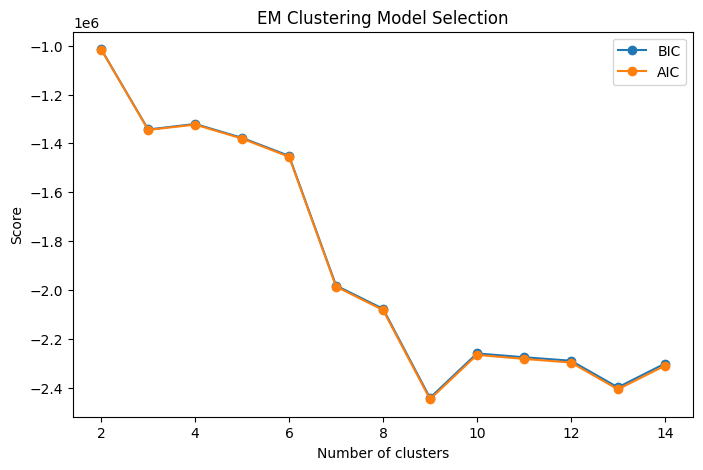

In [206]:
#Оптимальное число кластеров - BIC/AIC минимальны
plt.figure(figsize=(8,5))
plt.plot(K_range, bic_scores, marker='o', label='BIC')
plt.plot(K_range, aic_scores, marker='o', label='AIC')

plt.xlabel('Number of clusters')
plt.ylabel('Score')
plt.title('EM Clustering Model Selection')
plt.legend()

plt.show()

In [207]:
#Подбираем лучший тип ковариации
covariance_types = ['full', 'tied', 'diag', 'spherical']
best_score = -1
best_params = {}

for cov_type in covariance_types:
    # Подбираем число кластеров для каждого типа
    K_range = range(2, 15)
    bic_scores = []
    
    for k in K_range:
        gmm = GaussianMixture(n_components=k, covariance_type=cov_type, 
                             random_state=42, n_init=10)
        gmm.fit(X_em)
        bic_scores.append(gmm.bic(X_em))
    
    optimal_k = K_range[np.argmin(bic_scores)]
    
    # Оцениваем качество
    gmm = GaussianMixture(n_components=optimal_k, covariance_type=cov_type, 
                         random_state=42, n_init=10)
    clusters = gmm.fit_predict(X_em)
    score = silhouette_score(X_em, clusters)
    
    print(f"{cov_type}: k={optimal_k}, silhouette={score:.4f}")
    
    if score > best_score:
        best_score = score
        best_params = {'cov_type': cov_type, 'n_components': optimal_k}


full: k=13, silhouette=0.0003
tied: k=14, silhouette=0.0697
diag: k=14, silhouette=-0.0076
spherical: k=14, silhouette=0.1491


In [208]:
gmm = GaussianMixture(
    n_components=14,  
    covariance_type='tied',
    random_state=42,
    n_init=10,
    max_iter=500
)
clusters_em = gmm.fit_predict(X_em)
client_df['cluster_em'] = clusters_em

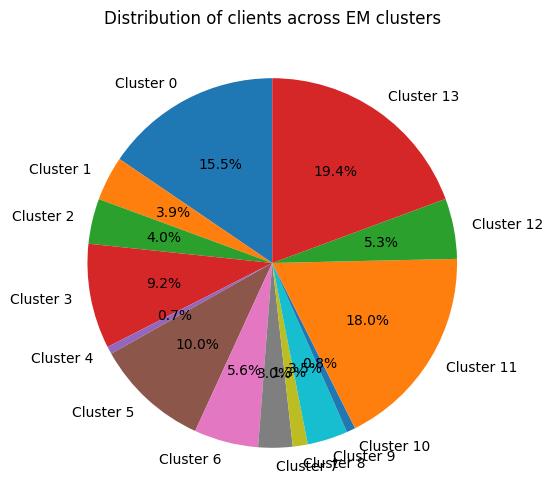

In [209]:
cluster_counts_em = client_df['cluster_em'].value_counts().sort_index()

plt.figure(figsize=(6,6))

plt.pie(cluster_counts_em,
        labels=[f'Cluster {i}' for i in cluster_counts_em.index],
        autopct='%1.1f%%',
        startangle=90)

plt.title('Distribution of clients across EM clusters')
plt.show()

In [264]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80795 entries, 0 to 80794
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   orders_count       80795 non-null  float64
 1   items_total        80795 non-null  Float64
 2   revenue_total      80795 non-null  float64
 3   avg_price          80795 non-null  float64
 4   margin_total       80795 non-null  float64
 5   unique_categories  80795 non-null  int64  
 6   recency_days       80795 non-null  int64  
 7   lifetime_days      80795 non-null  int64  
 8   avg_check          80795 non-null  float64
 9   items_per_order    80795 non-null  Float64
 10  cluster_5          80795 non-null  int32  
dtypes: Float64(2), float64(5), int32(1), int64(3)
memory usage: 6.6 MB


In [205]:
cols_to_drop = ['cluster_7']
numeric_df = client_df.select_dtypes(include='number').drop(columns=cols_to_drop, errors='ignore')

In [206]:
cluster_profiles = numeric_df.groupby('cluster_em').mean()

In [207]:
print(cluster_profiles.dtypes)

orders_count         float64
items_total          float64
revenue_total        float64
avg_price            float64
margin_total         float64
unique_categories    float64
recency_days         float64
lifetime_days        float64
avg_check            float64
items_per_order      float64
dtype: object


In [208]:
cluster_profiles = cluster_profiles.astype(float)

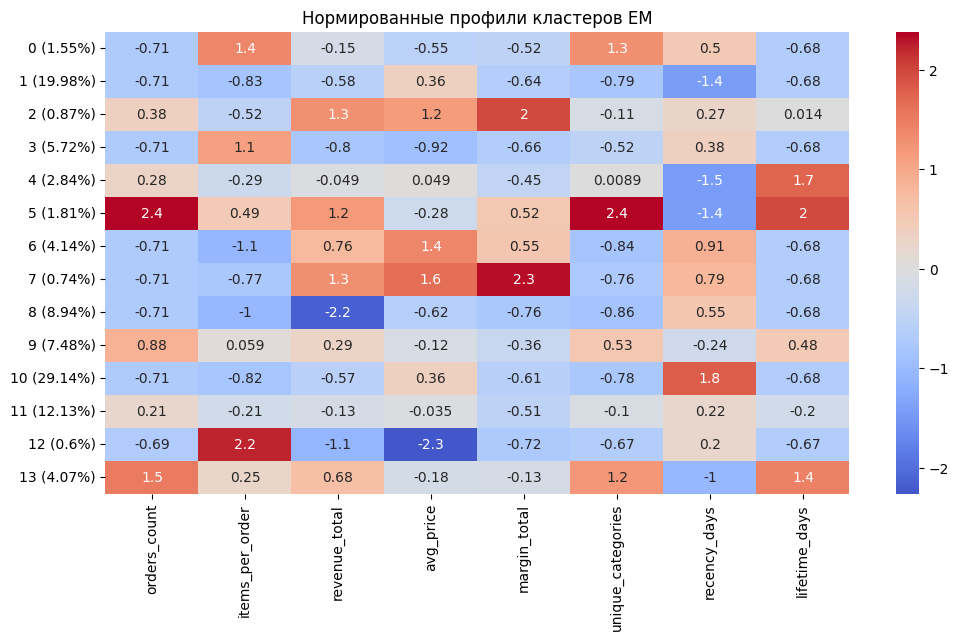

In [209]:

cluster_em_sizes = client_df['cluster_em'].value_counts().sort_index()
cluster_em_share = (cluster_em_sizes / len(client_df) * 100).round(2)

means_em = client_df.groupby('cluster_em')[features].mean().astype(float)

means_em.index = [f"{cluster} ({cluster_em_share[cluster]}%)" for cluster in means_em.index]

means_em_scaled = (means_em - means_em.mean()) / means_em.std()

# Тепловая карта
plt.figure(figsize=(12,6))
sns.heatmap(means_em_scaled, annot=True, cmap="coolwarm", center=0)
plt.title("Нормированные профили кластеров EM")
plt.show()

In [210]:
means_em_scaled.to_excel('тепловая_карта_EM.xlsx')

**Кластер 0 (0.65%)** — элитный сегмент: максимальные заказы (+2.31), высокая выручка (+1.66), максимальная маржинальность (+1.94), широкий ассортимент (+1.95), свежие покупки (-1.13), давние клиенты (+1.63).

**Кластер 1 (19.28%)** — массовый неактивный сегмент: низкие заказы (-0.80), выручка (-0.67), маржинальность (-0.61), узкий ассортимент (-0.87), но недавно активны (-1.07).

**Кластер 2 (1.21%)** — премиум-сегмент: максимальный средний чек (+1.99), максимальная маржинальность (+2.43), высокая выручка (+1.48), узкий ассортимент (-0.55).

**Кластер 3 (7.64%)** — средний сегмент: показатели близки к средним, небольшая длительность жизни (+0.56).

**Кластер 4 (33.55%)** — самый крупный спящий сегмент: минимальная выручка (-1.08), мало заказов (-0.70), узкий ассортимент (-0.78), высокая давность покупок (+1.36).

**Кластер 5 (4.21%)** — премиум-сегмент: высокий средний чек (+1.75), высокая маржинальность (+0.73), мало товаров в заказе (-0.93).

**Кластер 6 (1.8%)** — активный сегмент: много заказов (+1.55), широкий ассортимент (+1.64), свежие покупки (-1.21), давние клиенты (+1.63).

**Кластер 7 (2.56%)** — активный сегмент: хорошие заказы (+1.03), широкий ассортимент (+1.19), средние показатели по остальным метрикам.

**Кластер 8 (8.77%)** — проблемный сегмент: минимальная выручка (-2.12), самый низкий средний чек (-0.99), крайне низкие показатели по всем метрикам.

**Кластер 9 (3.24%)** — лояльный сегмент: максимальная длительность жизни (+1.81), самые свежие покупки (-1.44), средние заказы.

**Кластер 10 (3.1%)** — нишевый сегмент: много товаров в заказе (+0.84), широкий ассортимент (+0.82), низкая выручка.

**Кластер 11 (9.68%)** — ушедший сегмент: максимальная давность покупок (+1.89), мало товаров в заказе (-1.27), узкий ассортимент (-0.94).

**Кластер 12 (3.19%)** — нишевый сегмент: очень много товаров в заказе (+1.48), низкий средний чек (-1.12).

**Кластер 13 (1.13%)** — нишевый сегмент: максимальное количество товаров в заказе (+2.28), низкий средний чек (-1.02).

In [211]:
# KMeans (k=5)
sil_kmeans = silhouette_score(X_kmeans, client_df['cluster_5'])
print("Silhouette KMeans:", sil_kmeans)

# HDBSCAN (без шума)
mask_hdb = client_clusters['cluster_hdbscan'] != -1
sil_hdb = silhouette_score(
    X_hdbscan[mask_hdb],
    client_clusters.loc[mask_hdb, 'cluster_hdbscan']
)
print("Silhouette HDBSCAN:", sil_hdb)


# EM (Gaussian Mixture)
sil_em = silhouette_score(X_em, client_df['cluster_em'])
print("Silhouette EM:", sil_em)

Silhouette KMeans: 0.20110973308284877
Silhouette HDBSCAN: 0.021004849319350313
Silhouette EM: 0.06967728491794244


In [213]:
#Добавляем кластеры в исходный датасет
df = df.merge(client_df[['Телефон_new', 'cluster_5']], 
              on='Телефон_new', 
              how='left')

In [260]:
print(df['cluster_5'].value_counts().sort_index())
print(f"Пропусков в cluster_5: {df['cluster_5'].isna().sum()}")

cluster_5
0     38916
1    378633
2    205117
3     17196
4     55841
Name: count, dtype: int64
Пропусков в cluster_5: 0


In [341]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80795 entries, 0 to 80794
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Телефон_new        80795 non-null  object 
 1   orders_count       80795 non-null  float64
 2   items_total        80795 non-null  Float64
 3   revenue_total      80795 non-null  float64
 4   avg_price          80795 non-null  float64
 5   margin_total       80795 non-null  float64
 6   unique_categories  80795 non-null  int64  
 7   recency_days       80795 non-null  int64  
 8   lifetime_days      80795 non-null  int64  
 9   avg_check          80795 non-null  float64
 10  items_per_order    80795 non-null  Float64
 11  Месяц_Год          80795 non-null  object 
 12  cluster_5          80795 non-null  int32  
 13  cluster_7          80795 non-null  int32  
 14  cluster_4          80795 non-null  int32  
dtypes: Float64(2), float64(5), int32(3), int64(3), object(2)
memory usage:

In [336]:
#data_4 = client_df

In [342]:
client_df = data_4

In [346]:
client_df = client_df.drop(columns=['cluster_7', 'cluster_4', 'Месяц_Год'], errors='ignore')

In [347]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80795 entries, 0 to 80794
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Телефон_new        80795 non-null  object 
 1   orders_count       80795 non-null  float64
 2   items_total        80795 non-null  Float64
 3   revenue_total      80795 non-null  float64
 4   avg_price          80795 non-null  float64
 5   margin_total       80795 non-null  float64
 6   unique_categories  80795 non-null  int64  
 7   recency_days       80795 non-null  int64  
 8   lifetime_days      80795 non-null  int64  
 9   avg_check          80795 non-null  float64
 10  items_per_order    80795 non-null  Float64
 11  cluster_5          80795 non-null  int32  
dtypes: Float64(2), float64(5), int32(1), int64(3), object(1)
memory usage: 7.2+ MB


In [222]:
df.head()

,Дата,ДатаДоставки,НомерЗаказаНаСайте,НовыйСтатус,СуммаЗаказаНаСайте,СуммаДокумента,МетодДоставки,ФормаОплаты,Регион,Группа2,...,КоличествоПроданоКлиенту,ДатаЗаказаНаСайте,Телефон_new,Клиент,ID_SKU,ГородМагазина,МагазинЗаказа,МесяцЗаказа,year,cluster_5
0,2017-09-25 20:55:00,2017-10-06,5583799_TR,Доставлен,1058.0,1058.0,Магазины,Безналичная,Волжский,ИГРУШКИ,...,1,2017-09-25,55555748-48484848484870,гость,ID9010023489250,0,NaN,9,2017.0,0
1,2017-02-06 23:11:00,2017-02-09,3819017_TR,Доставлен,2000.0,2000.0,Магазины,Безналичная,Москва,ОБУВЬ,...,1,2017-02-06,55574848-48484848484870,Гость,IDL00044424957,0,NaN,2,2017.0,4
2,2017-10-09 02:07:00,2017-10-20,5720307_TR,Доставлен,1427.0,1427.0,Магазины,Безналичная,Сочи,"ТЕКСТИЛЬ, ТРИКОТАЖ",...,1,2017-10-09,55574848-48484949515179,Ирина,IDL00018271250,0,NaN,10,2017.0,2
3,2017-10-09 02:07:00,2017-10-20,5720307_TR,Доставлен,1427.0,1427.0,Магазины,Безналичная,Сочи,"ТЕКСТИЛЬ, ТРИКОТАЖ",...,1,2017-10-09,55574848-48484949515179,Ирина,IDL00017550654,0,NaN,10,2017.0,2
4,2017-10-09 02:07:00,2017-10-20,5720307_TR,Доставлен,1427.0,1427.0,Магазины,Безналичная,Сочи,"ТЕКСТИЛЬ, ТРИКОТАЖ",...,1,2017-10-09,55574848-48484949515179,Ирина,IDL00028435452,0,NaN,10,2017.0,2


In [223]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 695703 entries, 0 to 695702
Data columns (total 39 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   Дата                      695703 non-null  datetime64[ns]
 1   ДатаДоставки              695703 non-null  datetime64[ns]
 2   НомерЗаказаНаСайте        695703 non-null  object        
 3   НовыйСтатус               695703 non-null  category      
 4   СуммаЗаказаНаСайте        695703 non-null  float64       
 5   СуммаДокумента            695703 non-null  float64       
 6   МетодДоставки             695703 non-null  category      
 7   ФормаОплаты               695703 non-null  category      
 8   Регион                    693088 non-null  category      
 9   Группа2                   695703 non-null  category      
 10  Группа3                   695703 non-null  category      
 11  Группа4                   664259 non-null  category      
 12  Ти

In [215]:
client_df.head()

,Телефон_new,orders_count,items_total,revenue_total,avg_price,margin_total,unique_categories,recency_days,lifetime_days,avg_check,items_per_order,cluster_7,Месяц_Год,cluster_em
0,32555749-545749525150 .,0.526589,1.026672,2.072791,1.847096,174.66,1,327,0,2.072791,1.026672,5,"[2017-04, 2017-04, 2017-04, 2017-04, 2017-04]",3
1,49574954-56524849545119,0.526589,0.526589,2.256546,2.256546,-704.86,1,191,0,2.256546,0.526589,4,[2017-08],10
2,51534957-48525550515032,0.526589,0.869742,2.067591,1.914541,262.00,1,233,0,2.067591,0.869742,0,"[2017-07, 2017-07]",10
3,55494851-56495152535476,0.526589,0.526589,2.127868,2.127868,376.02,1,343,0,2.127868,0.526589,2,[2017-03],10
4,55515349-57484951525673,0.526589,0.526589,2.104731,2.104731,-186.00,1,181,0,2.104731,0.526589,4,[2017-08],10


In [227]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80795 entries, 0 to 80794
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   orders_count       80795 non-null  float64
 1   items_total        80795 non-null  Float64
 2   revenue_total      80795 non-null  float64
 3   avg_price          80795 non-null  float64
 4   margin_total       80795 non-null  float64
 5   unique_categories  80795 non-null  int64  
 6   recency_days       80795 non-null  int64  
 7   lifetime_days      80795 non-null  int64  
 8   avg_check          80795 non-null  float64
 9   items_per_order    80795 non-null  Float64
 10  cluster_5          80795 non-null  int32  
dtypes: Float64(2), float64(5), int32(1), int64(3)
memory usage: 6.6 MB


In [219]:
for col in client_df.select_dtypes(include=['Float64']).columns:
    client_df[col] = client_df[col].astype('float64')

In [226]:
client_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80795 entries, 0 to 80794
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   orders_count       80795 non-null  float64
 1   items_total        80795 non-null  Float64
 2   revenue_total      80795 non-null  float64
 3   avg_price          80795 non-null  float64
 4   margin_total       80795 non-null  float64
 5   unique_categories  80795 non-null  int64  
 6   recency_days       80795 non-null  int64  
 7   lifetime_days      80795 non-null  int64  
 8   avg_check          80795 non-null  float64
 9   items_per_order    80795 non-null  Float64
 10  cluster_5          80795 non-null  int32  
dtypes: Float64(2), float64(5), int32(1), int64(3)
memory usage: 6.6 MB


In [348]:
client_df.to_parquet('client_data.parquet', 
                     engine='fastparquet', 
                     index=False)

In [222]:
period_cols = []
for col in df.columns:
    if pd.api.types.is_period_dtype(df[col]):
        period_cols.append(col)
        print(f"  {col}: {df[col].dtype}")
for col in period_cols:
    df[col] = df[col].dt.to_timestamp()

  Месяц_Год: period[M]


/var/folders/21/d9w0s1wn3y772gh03j1bs5wm0000gn/T/ipykernel_37609/2643321456.py:3: DeprecationWarning: is_period_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.PeriodDtype)` instead
  if pd.api.types.is_period_dtype(df[col]):


In [225]:
df.to_parquet('df.parquet', 
                     engine='fastparquet', 
                     index=False)

In [133]:

!/Users/ekaterinazinoveva/Mag/bin/pip install fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 692.1/692.1 kB 487.0 kB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 693.2 kB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [fastparquet]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Users/ekaterinazinoveva/Mag/bin/python3.14 -m pip install --upgrade pip


In [233]:
print(f"Диапазон дат: {df['ДатаЗаказаНаСайте'].min()} - {df['ДатаЗаказаНаСайте'].max()}")

Диапазон дат: 2017-01-01 00:00:00 - 2018-02-28 00:00:00
